In [ ]:
!nvidia-smi

Thu Mar 12 13:11:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   36C    P0             57W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!pip install wandb
!pip install python-Levenshtein
!pip install torchinfo
!pip install kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.8 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio.transforms as tat

from torchinfo import summary
from torch.autograd import Variable
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

import gc
import os
import math
import yaml
import random
import zipfile
import datetime
from pathlib import Path

import glob
import wandb
import numpy as np
import pandas as pd
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

''' Imports for decoding and distance calculation. '''
import Levenshtein

import warnings
warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device: ", device)

Device:  cuda


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
!unzip /content/drive/MyDrive/data/automatic-speech-recognition-s24.zip -d /content/data

流式输出内容被截断，只能显示最后 5000 行内容。
  inflating: /content/data/11785-HW4P2/train-clean-50/transcripts/1482-140071-0030.npy  
  inflating: /content/data/11785-HW4P2/train-clean-50/transcripts/1482-140071-0031.npy  
  inflating: /content/data/11785-HW4P2/train-clean-50/transcripts/1482-140071-0032.npy  
  inflating: /content/data/11785-HW4P2/train-clean-50/transcripts/1482-140071-0033.npy  
  inflating: /content/data/11785-HW4P2/train-clean-50/transcripts/1482-140071-0034.npy  
  inflating: /content/data/11785-HW4P2/train-clean-50/transcripts/1482-140072-0000.npy  
  inflating: /content/data/11785-HW4P2/train-clean-50/transcripts/1482-140072-0001.npy  
  inflating: /content/data/11785-HW4P2/train-clean-50/transcripts/1482-140072-0002.npy  
  inflating: /content/data/11785-HW4P2/train-clean-50/transcripts/1482-140072-0003.npy  
  inflating: /content/data/11785-HW4P2/train-clean-50/transcripts/1482-140072-0004.npy  
  inflating: /content/data/11785-HW4P2/train-clean-50/transcripts/1482-140072-0005.

In [ ]:
%%writefile config.yaml

###### Dataset -----------------------------------------------------------------
train_dataset   : "train-clean-100"     # train-clean-50 (primarily for debugging purposes), train-clean-100
cepstral_norm   : True
input_dim       : 27
batch_size      : 256                    # decrease this as you modify the network architecture

###### Encoder Parameters ------------------------------------------
## Universal (Part I and II)
enc_dropout     : 0.3                   # [0.1, 0.4]
## Transformer-related (Part II)
enc_num_layers  : 1                     # [1, 3]
enc_num_heads   : 3                     # [1, 4]

###### Decoder Parameters ------------------------------------------
## Transformer-related (Part I and II)
dec_dropout     : 0.2                 # [0.1, 0.4]
dec_num_layers  : 3                     # [1, 3]
dec_num_heads   : 3                   # [1, 4]

###### Network Parameters ------------------------------------------------------
d_model         : 512                   # [256, 1024]
d_ff            : 2048                  # [512, 4096]

###### Learning Rate ---------------------------------------------------------------
learning_rate   : 2E-4                  # [1E-3, 1E-4], this will depend on the specified optimizer
learning_rate_2 : 5E-5

###### Optimizer ---------------------------------------------------------------
optimizer       : "AdamW"               # Adam, AdamW

## if SGD
momentum        : 0.0
nesterov        : True

###### Scheduler ---------------------------------------------------------------
scheduler       : "ReduceLR"     # CosineAnnealing, ReduceLR

## if ReduceLR

## we are validating every 2 epochs but scheduler acts on every epoch. Set patience accordingly
## patience less than validation frquency can mean learning rate always dropping after patience epochs
## specify a suitable threshold too
factor          : 0.5
patience        : 6

###### Training Parameters -----------------------------------------------------
epochs          : 280

###### Name --------------------------------------------------------------------
Name: "ww"                                # write your name here for study group

Overwriting config.yaml


In [ ]:
with open("config.yaml") as file:
    config = yaml.safe_load(file)

In [ ]:
config

{'train_dataset': 'train-clean-100',
 'cepstral_norm': True,
 'input_dim': 27,
 'batch_size': 256,
 'enc_dropout': 0.3,
 'enc_num_layers': 1,
 'enc_num_heads': 3,
 'dec_dropout': 0.2,
 'dec_num_layers': 3,
 'dec_num_heads': 3,
 'd_model': 512,
 'd_ff': 2048,
 'learning_rate': '2E-4',
 'learning_rate_2': '5E-5',
 'optimizer': 'AdamW',
 'momentum': 0.0,
 'nesterov': True,
 'scheduler': 'ReduceLR',
 'factor': 0.5,
 'patience': 6,
 'epochs': 280,
 'Name': 'ww'}

In [ ]:
VOCAB = [
    "<pad>", "<sos>", "<eos>",
    "A",   "B",    "C",    "D",
    "E",   "F",    "G",    "H",
    "I",   "J",    "K",    "L",
    "M",   "N",    "O",    "P",
    "Q",   "R",    "S",    "T",
    "U",   "V",    "W",    "X",
    "Y",   "Z",    "'",    " ",
]

VOCAB_MAP = {VOCAB[i]:i for i in range(0, len(VOCAB))}

PAD_TOKEN = VOCAB_MAP["<pad>"]
SOS_TOKEN = VOCAB_MAP["<sos>"]
EOS_TOKEN = VOCAB_MAP["<eos>"]

print(f"Length of Vocabulary    : {len(VOCAB)}")
print(f"VOCAB                   : {VOCAB}")
print(f"VOCAB_MAP: {VOCAB_MAP}")
print(f"PAD_TOKEN               : {PAD_TOKEN}")
print(f"SOS_TOKEN               : {SOS_TOKEN}")
print(f"EOS_TOKEN               : {EOS_TOKEN}")

Length of Vocabulary    : 31
VOCAB                   : ['<pad>', '<sos>', '<eos>', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', "'", ' ']
VOCAB_MAP: {'<pad>': 0, '<sos>': 1, '<eos>': 2, 'A': 3, 'B': 4, 'C': 5, 'D': 6, 'E': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26, 'Y': 27, 'Z': 28, "'": 29, ' ': 30}
PAD_TOKEN               : 0
SOS_TOKEN               : 1
EOS_TOKEN               : 2


In [ ]:
class SpeechDataset(Dataset):
    def __init__(self, root, VOCAB_MAP, SOS_TOKEN, EOS_TOKEN, PAD_TOKEN, train=True, CEPSTRAL=True) -> None:
        super().__init__()

        self.root = Path(root) if isinstance(root, str) else root
        self.mfcc_dir = self.root.joinpath("mfcc")
        self.transcript_dir = self.root.joinpath("transcripts")

        self.mfcc_files = sorted(self.mfcc_dir.glob("*.npy"))
        self.transcript_files = sorted(self.transcript_dir.glob("*.npy"))

        assert len(self.mfcc_files) == len(self.transcript_files)

        self.VOCAP_MAP = VOCAB_MAP
        self.train = train
        self.CEPSTRAL = CEPSTRAL
        self.SOS_TOKEN = SOS_TOKEN
        self.EOS_TOKEN = EOS_TOKEN
        self.PAD_TOKEN = PAD_TOKEN

        if self.train:
            self.audio_transforms = nn.Sequential(
                tat.FrequencyMasking(freq_mask_param=10),
                tat.TimeMasking(time_mask_param=40)
            )
        else:
            self.audio_transforms = None

        self.length = len(self.transcript_files)

    def _load_and_process_mfcc(self, mfcc_path):
        mfcc = np.load(mfcc_path, mmap_mode="r").astype(np.float32)

        if self.CEPSTRAL:
            mfcc = (mfcc - np.mean(mfcc, axis=0)) / (np.std(mfcc, axis=0) + 1e-8)

        mfcc = torch.from_numpy(mfcc)

        return mfcc

    def _process_transcript(self, transcript_path):
        # drop pad and " "
        transcript = np.load(transcript_path)[1:-1]

        transcript_start_shifted = torch.tensor([self.SOS_TOKEN] + [self.VOCAP_MAP[t] for t in transcript])
        transcript_end_shifted = torch.tensor([self.VOCAP_MAP[t] for t in transcript] + [self.EOS_TOKEN])

        return transcript_start_shifted, transcript_end_shifted

    def __len__(self):
        return self.length

    def __getitem__(self, index):

        mfcc_path = self.mfcc_files[index]
        transcript_path = self.transcript_files[index]

        mfcc = self._load_and_process_mfcc(mfcc_path)
        transcript_start_shifted, transcript_end_shifted = self._process_transcript(transcript_path)

        return mfcc, transcript_start_shifted, transcript_end_shifted

    def collate_fn(self, batch):

        batch_mfcc = [b[0] for b in batch]
        batch_transcript_start_shifted = [b[1] for b in batch]
        batch_transcript_end_shifted = [b[2] for b in batch]


        lengths_mfcc = torch.tensor([x.size(0) for x in batch_mfcc])
        lengths_transcripts = torch.tensor([y.size(0) for y in batch_transcript_start_shifted])

        batch_mfcc_pad = pad_sequence(batch_mfcc, batch_first=True, padding_value=self.PAD_TOKEN)
        batch_transcript_start_shifted_pad = pad_sequence(batch_transcript_start_shifted, batch_first=True, padding_value=self.PAD_TOKEN)
        batch_transcript_end_shifted_pad = pad_sequence(batch_transcript_end_shifted, batch_first=True, padding_value=self.PAD_TOKEN)

        if self.audio_transforms:
            batch_mfcc_pad = batch_mfcc_pad.transpose(1, 2)
            batch_mfcc_pad = self.audio_transforms(batch_mfcc_pad)
            batch_mfcc_pad = batch_mfcc_pad.transpose(1, 2)

        return batch_mfcc_pad, batch_transcript_start_shifted_pad, batch_transcript_end_shifted_pad, lengths_mfcc, lengths_transcripts


In [ ]:
class SpeechTestDataset(Dataset):
    def __init__(self, root, PAD_TOKEN, CEPSTRAL=True) -> None:
        super().__init__()

        self.root = Path(root) if isinstance(root, str) else root
        self.mfcc_dir = self.root.joinpath("mfcc")

        self.mfcc_files = sorted(self.mfcc_dir.glob("*.npy"))

        self.CEPSTRAL = CEPSTRAL
        self.PAD_TOKEN = PAD_TOKEN

        self.length = len(self.mfcc_files)

    def _load_and_process_mfcc(self, mfcc_path):
        mfcc = np.load(mfcc_path, mmap_mode="r").astype(np.float32)

        if self.CEPSTRAL:
            mfcc = (mfcc - np.mean(mfcc, axis=0)) / (np.std(mfcc, axis=0) + 1e-8)

        mfcc = torch.from_numpy(mfcc)

        return mfcc


    def __len__(self):
        return self.length

    def __getitem__(self, index):

        mfcc_path = self.mfcc_files[index]

        mfcc = self._load_and_process_mfcc(mfcc_path)

        return mfcc

    def collate_fn(self, batch):

        batch_mfcc = list(batch)

        lengths_mfcc = torch.tensor([x.size(0) for x in batch_mfcc])

        batch_mfcc_pad = pad_sequence(batch_mfcc, batch_first=True, padding_value=self.PAD_TOKEN)

        return batch_mfcc_pad, lengths_mfcc

In [ ]:
# @NOTE: use the config file to specify PARTITION and CEPSTRAL
TRAIN_ROOT = "/content/data/11785-HW4P2/train-clean-100"                # Enter your data directory here.
VAL_ROOT = "/content/data/11785-HW4P2/dev-clean"
TEST_ROOT = "/content/data/11785-HW4P2/test-clean"
CEPSTRAL = True                # Enter your cepstral_norm parameter here.

train_dataset   = SpeechDataset(
    root=TRAIN_ROOT,
    VOCAB_MAP=VOCAB_MAP,
    SOS_TOKEN=SOS_TOKEN,
    EOS_TOKEN=EOS_TOKEN,
    PAD_TOKEN=PAD_TOKEN,
    train=True,
    CEPSTRAL=CEPSTRAL
)

val_dataset     = SpeechDataset(
    root=VAL_ROOT,
    VOCAB_MAP=VOCAB_MAP,
    SOS_TOKEN=SOS_TOKEN,
    EOS_TOKEN=EOS_TOKEN,
    PAD_TOKEN=PAD_TOKEN,
    train=False,
    CEPSTRAL=CEPSTRAL
)

test_dataset    = SpeechTestDataset(
    root=TEST_ROOT,
    PAD_TOKEN=PAD_TOKEN,
    CEPSTRAL=True
)

gc.collect()

0

In [ ]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

28539
2703
2620


In [ ]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    collate_fn=train_dataset.collate_fn
)

val_loader      = torch.utils.data.DataLoader(
    dataset     = val_dataset,
    batch_size  = config["batch_size"],
    shuffle     = False,
    num_workers = 4,
    pin_memory  = True,
    collate_fn  = val_dataset.collate_fn,
)

test_loader     = torch.utils.data.DataLoader(
    dataset     = test_dataset,
    batch_size  = config["batch_size"],
    shuffle     = False,
    num_workers = 4,
    pin_memory  = True,
    collate_fn  = test_dataset.collate_fn,
)

print("No. of Train MFCCs   : ", train_dataset.__len__())
print("Batch Size           : ", config["batch_size"])
print("Train Vatches        : ", train_loader.__len__())
print("Val Batches          : ", val_loader.__len__())
print("Test Batches         : ", test_loader.__len__())

No. of Train MFCCs   :  28539
Batch Size           :  256
Train Vatches        :  112
Val Batches          :  11
Test Batches         :  11


In [ ]:
''' Sanity Check '''

print("Checking the Shapes of the Data --\n")

for batch in train_loader:
    x_pad, y_shifted_pad, y_golden_pad, x_len, y_len, = batch

    print(f"x_pad shape:\t\t{x_pad.shape}")
    print(f"x_len shape:\t\t{x_len.shape}\n")

    print(f"y_shifted_pad shape:\t{y_shifted_pad.shape}")
    print(f"y_golden_pad shape:\t{y_golden_pad.shape}")
    print(f"y_len shape:\t\t{y_len.shape}\n")

    # print(y_shifted_pad)

    break

Checking the Shapes of the Data --

x_pad shape:		torch.Size([256, 1707, 27])
x_len shape:		torch.Size([256])

y_shifted_pad shape:	torch.Size([256, 298])
y_golden_pad shape:	torch.Size([256, 298])
y_len shape:		torch.Size([256])



# Introduction

Transformers are highly effective for speech recognition tasks because they utilize self-attention mechanisms, enabling them to analyze entire sequences of audio data in one shot. This allows for a nuanced understanding of long-range dependencies and the complex temporal dynamics inherent in speech. Compared to traditional models, transformers offer improved accuracy and efficiency, adeptly handling variations in speech patterns, accents, and intonations; thus, making them exceptionally suitable for advanced speech recognition applications.

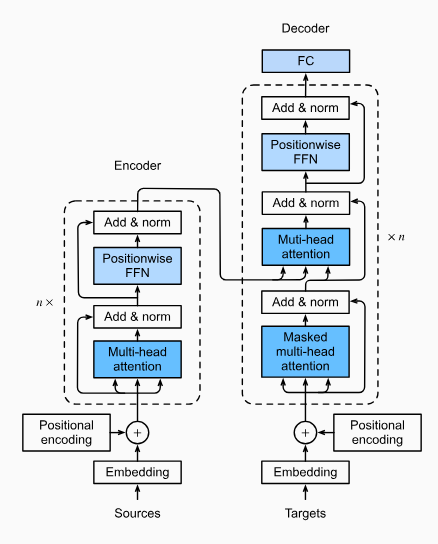

Given the complicated nature of these models, training in this homework will be a little different from other homeworks.<br>
We will employ the following to effectively train the transformer with fewer resources (data and compute power).
<br>
* **Data Complexity and Model Capacity**:  Starting with a CNN-LSTM for input sequences captures temporal dynamics and dependencies early on, simplifying initial learning. This is effective for data with strong temporal or sequential patterns, which LSTMs excel at handling. We will use an already trained model (trained in HW3P2).


* **Gradual (Incremental) Learning**: Starting with a simpler model (like an LSTM) allows the neural network to first learn the basic structures and patterns in the data. When we later introduce more complex mechanisms (like a transformer encoder), the model already has a foundational understanding of the data. This foundation can lead to a smoother and more effective learning process when the complexity of the model increases. In other words, we are using a simple, pretrained LSTM encoder as the basis for our transformer decoder and incrementally adding complexity!

* **Learning Efficiency**: By freezing certain parts of the model during different stages of training, we focus the learning capacity of the network on specific modules, making the training process more efficient. This stepwise unfreezing and training allows different components of the model to adapt gradually, which can be very useful when integrating parts of the model that learn at different rates.

* **Adaptation to Data Characteristics**: This strategy implicitly takes advantage of the data's characteristics by adjusting the model's architecture and training procedure to better suit the data's structure. For instance, if the data contains intricate sequential patterns, starting with an LSTM can harness these patterns effectively. Then, by introducing a transformer encoder, the model can further learn to capture complex, long-range dependencies within the data, something transformers are exceptionally good at.


## Utilities

To make make building the transformer easy, we will define various utility functions and classes which corresponds to the various modules of the transformer. All Components are provided for you but your task will be too understand the modules as you will need  them in answering Canvas quizzes as well as implementing other parts of this notebook. Please refer to the write-up for more information.

In [ ]:
def create_mask_1(padded_input, input_lengths=None, pad_idx=None):
    """ Create a mask to identify non-padding positions.

    Args:
        padded_input: The input tensor with padding, shape (N, T, ...) or (N, T).
        input_lengths: Optional, the actual lengths of each sequence before padding, shape (N,).
        pad_idx: Optional, the index used for padding tokens.

    Returns:
        A mask tensor with shape (N, T, 1), where non-padding positions are marked with 1 and padding positions are marked with 0.
    """

    assert input_lengths is not None or pad_idx is not None


    if input_lengths is not None:
        N, T = padded_input.shape[0:2]
        mask = torch.arange(T).expand(N, T) < input_lengths.unsqueeze(1)
        non_pad_mask = mask.float()

    if pad_idx is not None:
        assert padded_input.dim() == 2
        non_pad_mask = padded_input.ne(pad_idx).float()

    # (N, T, 1) can broadcast
    return non_pad_mask.unsqueeze(-1)

In [ ]:
def create_mask_2(seq, pad_idx=None):
    """ Create a mask to prevent positions from attending to subsequent positions.

    Args:
        seq: The input sequence tensor, shape (batch_size, sequence_length).

    Returns:
        A mask tensor with shape (batch_size, sequence_length, sequence_length),
            where positions are allowed to attend to previous positions but not to subsequent positions.
    """

    batch_size, sequence_length = seq.shape

    # causal mask
    subseqent_mask = torch.triu(
        torch.ones(size=(sequence_length, sequence_length), device=seq.device),
        diagonal=1
    )

    mask = subseqent_mask.unsqueeze(0).expand(batch_size, -1, -1).to(seq.device)


    ''' Create a mask to ignore padding positions in the key sequence during attention calculation. '''

    if pad_idx is not None:
        pad_mask = seq.eq(pad_idx).to(seq.device)
        pad_mask = pad_mask.unsqueeze(1).expand(-1, sequence_length, -1)
        mask = (pad_mask + mask).gt(0)
    else:
        mask = mask.gt(0)

    return mask

In [ ]:
def create_mask_3(padded_input, input_lengths, expand_length):
    """ Create an attention mask to ignore padding positions in the input sequence during attention calculation.

    Args:
        padded_input: The input tensor with padding, shape (N, Ti, ...).
        input_lengths: The actual lengths of each sequence before padding, shape (N,).
        expand_length: The length to which the attention mask should be expanded,
            usually equal to the length of the sequence that the attention scores will be applied to.

    Returns:
        An attention mask tensor with shape (N, expand_length, Ti),
            where padding positions in the input sequence are marked with 1 and other positions are marked with 0.
    """

    non_pad_mask = create_mask_1(padded_input, input_lengths)
    pad_mask = non_pad_mask.squeeze(-1).lt(1)

    attn_mask = pad_mask.unsqueeze(1).expand(-1, expand_length, -1)

    return attn_mask

In [ ]:
class ScaledDotProductAttention(torch.nn.Module):
    ''' Scaled Dot-Product Attention '''
    def __init__(self, temperature, attn_dropout=0.1) -> None:
        super().__init__()

        self.temperature = temperature
        self.dropout = nn.Dropout(attn_dropout)
        # only softmax in key dim
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, q, k, v, mask=None):

        attn = torch.matmul(q, k.transpose(-2, -1)) / self.temperature

        if mask is not None:
            mask_value = -1e+30 if attn.dtype == torch.float32 else -1e+4
            attn = attn.masked_fill(mask.to(attn.device), mask_value)

        attn = self.softmax(attn)
        attn = self.dropout(attn)
        output = torch.matmul(attn, v)

        return output, attn

In [ ]:
def save_attention_plot(attention_weights, epoch=0, folder=""):
    """
    function for save attention weights plot to a file
    """

    plt.clf()
    sns.heatmap(attention_weights, cmap="GnBu")

    plt.savefig(f"{folder}cross_attention-epoch{epoch}.png")


In [ ]:
class MultiHeadAttention(torch.nn.Module):
    ''' Multi-Head Attention Module '''
    def __init__(self, n_head, d_model, dropout=0.1) -> None:
        super().__init__()

        self.n_head = n_head
        self.d_k = d_model // n_head
        self.d_v = d_model // n_head

        self.w_qs = nn.Linear(d_model, n_head * self.d_k)
        self.w_ks = nn.Linear(d_model, n_head * self.d_k)
        self.w_vs = nn.Linear(d_model, n_head * self.d_v)
        # Xavier init
        nn.init.normal_(self.w_qs.weight, mean=0, std=np.sqrt(2.0 / (d_model + self.d_k)))
        nn.init.normal_(self.w_ks.weight, mean=0, std=np.sqrt(2.0 / (d_model + self.d_k)))
        nn.init.normal_(self.w_vs.weight, mean=0, std=np.sqrt(2.0 / (d_model + self.d_v)))

        self.attention = ScaledDotProductAttention(
            temperature=np.power(self.d_k, 0.5),
            attn_dropout=dropout
        )

        self.fc = nn.Linear(n_head * self.d_v, d_model)

        nn.init.xavier_normal_(self.fc.weight)

        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        d_k, d_v, n_head = self.d_k, self.d_v, self.n_head

        """
        q : (B, Lq, D)
        k : (B, Lk, D)
        v : (B, Lv, D)
        mask : (B, Lq, Lk)  或 (B, 1, Lk)
        """

        batch_size, len_q, d_model = q.shape
        batch_size, len_k, d_model = k.shape
        batch_size, len_v, d_model = v.shape

        q = self.w_qs(q).view(batch_size, len_q, n_head, d_k)
        k = self.w_ks(k).view(batch_size, len_k, n_head, d_k)
        v = self.w_vs(v).view(batch_size, len_v, n_head, d_v)

        # Rearange the dim to group head together for parallel
        q = q.permute(2, 0, 1, 3).contiguous().view(-1, len_q, d_k) # batch_size * n_head, len_q, d_k
        k = k.permute(2, 0, 1, 3).contiguous().view(-1, len_k, d_k)
        v = v.permute(2, 0, 1, 3).contiguous().view(-1, len_v, d_v)


        if mask is not None:
            mask = mask.repeat(n_head, 1, 1) # mask batch_size * n_head

        output, attn = self.attention(q, k, v, mask=mask) # attn : (H*B, Lq, Lk)

        output = output.view(n_head, batch_size, len_q, d_v)
        output = output.permute(1, 2, 0, 3).contiguous().view(batch_size, len_q, -1)
        output = self.fc(output)
        output = self.dropout(output)

        return output, attn


## Transformer Modules

### Positional Encoding

In [ ]:
class PositionalEncoding(torch.nn.Module):
    def __init__(self, d_model, max_len=5000) -> None:
        super().__init__()

        pe = torch.zeros(size=(max_len, d_model))
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # add batch_size dim
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x : (B, L, D)
        return x + self.pe[:, :x.size(1)]

### Feed Forward Networks

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=2048, dropout=0.1) -> None:
        super().__init__()

        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        x = self.linear1(x)
        x = nn.functional.mish(x)
        x = self.dropout(x)
        x = self.linear2(x)

        return x

# PART #1 (Preliminary Submission)

In this part we will use a simple CNN-LSTM as an encoder with a Transformer Decoder (with Self-Attention and Cross-Attention).

## CNN-LSTM Encoder

In [ ]:
class Permute(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)

In [ ]:
class pBLSTM(nn.Module):
    def __init__(self, input_size, hidden_size) -> None:
        super().__init__()

        self.blstm = nn.LSTM(input_size=input_size*2, hidden_size=hidden_size, bidirectional=True, batch_first=True)

    def trunc_reshape(self, x, x_lens):
        if x.shape[1] % 2 == 1:
            x = x[:, :-1, :]
        x = x.reshape((x.shape[0], x.shape[1] // 2, x.shape[2] * 2))
        x_lens = (x_lens // 2).type(torch.int)

        return x, x_lens

    def forward(self, x_packed):
        x_padded, x_lens = pad_packed_sequence(x_packed, batch_first=True)
        x_padded, x_lens = self.trunc_reshape(x_padded, x_lens)
        x_packed = pack_padded_sequence(x_padded, x_lens.cpu(), batch_first=True, enforce_sorted=False)
        output_packed, _ = self.blstm(x_packed)

        return output_packed


In [ ]:
# 同一个 mask 在所有 timestep 使用避免破会时间依赖
class LockedDropout(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        self.dropout = dropout

    def forward(self, x):

        if not self.training or self.dropout == 0:
            return x

        x_unpacked, x_lens = pad_packed_sequence(x, batch_first=True)
        # x_unpacked : (B, L, H)

        B, L, H = x_unpacked.size()

        mask = torch.bernoulli(
            torch.full((B, 1, H),
            1 - self.dropout,
            device=x_unpacked.device)
        ) / (1 - self.dropout)

        mask = mask.expand_as(x_unpacked)

        out = mask * x_unpacked

        return pack_padded_sequence(
            out,
            lengths=x_lens.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

In [ ]:
class PermuteBlock(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)

class CNN_LSTM_Enocder(nn.Module):
    def __init__(self, input_size, encoder_hidden_size, enc_dropout=0.2) -> None:
        super().__init__()

        self.embedding = nn.Sequential(
            nn.Conv1d(input_size, 2 *input_size, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(2 * input_size),
            nn.ReLU(inplace=True),
            nn.Conv1d(2 * input_size, 4 * input_size, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(4 * input_size),
            nn.ReLU(inplace=True)
        )

        self.blistm = nn.LSTM(
            input_size=4 * input_size,
            hidden_size=encoder_hidden_size,
            bidirectional=True,
            batch_first=True,
            dropout=enc_dropout
        )

        self.pBLSTMs = nn.Sequential(
            pBLSTM(2 * encoder_hidden_size, encoder_hidden_size),
            LockedDropout(dropout=2 * enc_dropout),
            pBLSTM(2 * encoder_hidden_size, 2 * encoder_hidden_size),
            LockedDropout(dropout=enc_dropout),
        )

        self.permute = PermuteBlock()

    def forward(self, x, x_lens):
        x = self.permute(x)
        x = self.embedding(x)
        x = self.permute(x)

        x_packed = pack_padded_sequence(x, x_lens.cpu(), batch_first=True, enforce_sorted=False)
        x_packed, _ = self.blistm(x_packed)
        x_packed = self.pBLSTMs(x_packed)
        encoder_outputs, encoder_lens = pad_packed_sequence(x_packed, batch_first=True)

        return encoder_outputs, encoder_lens

## Transformer Decoder

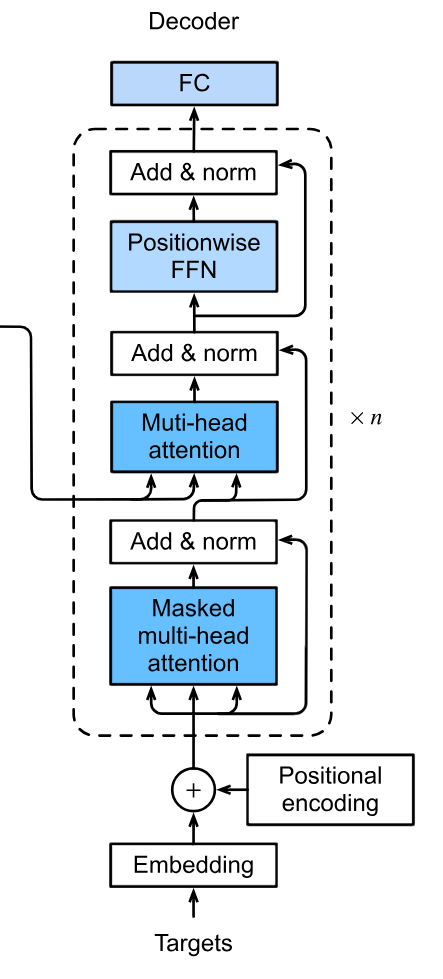

Tips to complete the Decoder below.

* Can you seperate the decoder layers from the whole decoder?
* How many multi-head attention do we have in the figure above.
* How many layer normalizations?
* How do we make the residual connections?

For Forward Method:
* What are the inputs to various multi-head attention modules?
* How do we make the residual connection (do we need dropout)?


In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1) -> None:
        super().__init__()

        self.mha1 = MultiHeadAttention(num_heads, d_model, dropout)
        self.mha2 = MultiHeadAttention(num_heads, d_model, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)

        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.layernorm3 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, padded_targets, enc_output, enc_input_lengths, dec_enc_attn_mask, pad_mask, slf_attn_mask):
        attn1, attn_weights_block1 = self.mha1(padded_targets, padded_targets, padded_targets, slf_attn_mask)

        attn1 = padded_targets + self.dropout1(attn1)

        attn1 = self.layernorm1(attn1)

        attn2, attn_weights_block2 = self.mha2(attn1, enc_output, enc_output, dec_enc_attn_mask)

        attn2 = attn1 + self.dropout2(attn2)

        attn2 = self.layernorm2(attn2)

        ffn_output = self.ffn(attn2)

        ffn_output = attn2 + self.dropout3(ffn_output)

        ffn_output = self.layernorm3(ffn_output)

        return attn_weights_block1, attn_weights_block2, ffn_output

In [ ]:
class Decoder(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, d_ff, dropout,
            target_vocab_size, max_seq_length, eos_token, sos_token, pad_token) -> None:
        super().__init__()

        self.EOS_TOKEN = eos_token
        self.SOS_TOKEN = sos_token
        self.PAD_TOKEN = pad_token

        self.max_seq_length = max_seq_length
        self.num_layers = num_layers

        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )

        self.target_embedding = nn.Embedding(target_vocab_size, d_model, padding_idx=pad_token)
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_seq_length)
        self.final_linear = torch.nn.Linear(d_model, target_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, padded_targets, enc_output, enc_input_lengths):

        # create a padding mask for the padded_targets with <PAD_TOKEN>
        pad_mask = padded_targets.eq(self.PAD_TOKEN)

        # creating an attention mask for the future subsequences (look-ahead mask)
        # print(padded_targets.shape)
        slf_attn_mask_subseq = create_mask_2(padded_targets)

        # creating attention mask to ignore padding positions in the input sequence during attention calculation
        dec_enc_attn_mask = create_mask_3(enc_output, enc_input_lengths, padded_targets.size(1))

        # computing embeddings for the target sequence
        x = self.target_embedding(padded_targets)

        # computing Positional Encodings with the embedded targets and apply dropout
        x = self.positional_encoding(x)
        x = self.dropout(x)

        # passing through decoder layers
        # @NOTE: store your mha1 and mha2 attention weights inside a dictionary
        # @NOTE: you will want to retrieve these later so store them with a useful name

        attn_weights = {}
        for i in range(self.num_layers):
            attn_weights[f"mha1_{i}"], attn_weights[f"mha2_{i}"], x = self.dec_layers[i](
                x, enc_output, enc_input_lengths, dec_enc_attn_mask, pad_mask, slf_attn_mask_subseq
            )

        # linear layer (Final Projection) for next character prediction
        seq_out = self.final_linear(x)

        # return the network output and the dictionary of attention weights
        return seq_out, attn_weights

    def recognize_greedy_search(self, enc_outputs, enc_input_lengths):
        ''' passes the encoder outputs and its corresponding lengths through autoregressive network

            @NOTE: You do not need to make changes to this method.
        '''

        batch_size = enc_outputs.size(0)

        # start with the <SOS> token for each sequence in the batch
        target_seq = torch.full(size=(batch_size, 1), fill_value=self.SOS_TOKEN, dtype=torch.long).to(enc_outputs.device)
        finished = torch.zeros(size=(batch_size,), dtype=torch.bool).to(enc_outputs.device)

        for _ in range(self.max_seq_length):
            # preparing attention masks
            # filled with ones becaues we want to attend to all the elements in the sequence
            pad_mask = torch.ones_like(target_seq).float().unsqueeze(-1) # (batch_size, 1)
            slf_attn_mask_subseq = create_mask_2(target_seq)

            x = self.target_embedding(target_seq)
            x = self.positional_encoding(x)

            for i in range(self.num_layers):
                _, _, x = self.dec_layers[i](
                    x, enc_outputs, enc_input_lengths, None, pad_mask, slf_attn_mask_subseq
                )

            # selecting the token with the highest probability
            # @NOTE: this is the autoregressive nature of the network!
            seq_output = self.final_linear(x[:, -1, :]) # x shape (batch_size, t, d_model)

            logits = nn.functional.log_softmax(seq_output, dim=1) # (batch_size, vocab_size)
            next_token = torch.argmax(logits, dim=-1).unsqueeze(-1)

            # appending the token to the sequence
            target_seq = torch.concat([target_seq, next_token], dim=-1)

            # checking if <EOS> token is generated

            eos_mask = next_token.squeeze(1) == self.EOS_TOKEN

            # or opration, if both or one of them is true store the value of the finished sequence in finished variable
            finished |= eos_mask
            # end if all sequences have generated the EOS token
            if finished.all(): break

        # remove the initial <SOS> token and pad sequences to the same length
        target_seq = target_seq[:, 1:]
        cur_length = target_seq.size(1)
        target_seq = nn.functional.pad(
            target_seq, (0, self.max_seq_length - cur_length), value=self.PAD_TOKEN
        )

        return target_seq

## CNN-LSTM Encoder + Speech Transformer Decoder

In this section, let's build the first (simplest) Transformer network by combining the CNN-LSTM encoder and our Transformer Decoder.

In [ ]:
class SpeechTransformer(nn.Module):

    def __init__(self, input_dim, dec_num_layers, dec_num_heads,
                    d_model, d_ff, target_vocab_size, eos_token, sos_token,
                    pad_token, enc_dropout, dec_dropout, max_seq_length=512):
        super().__init__()

        self.encoder = CNN_LSTM_Enocder(input_dim, 256, enc_dropout)
        # 用来将维度从1024映射到d_model 并且提升表达能力
        self.proj = nn.Linear(1024, d_model)
        self.layernorm  = nn.LayerNorm(d_model)

        self.decoder = Decoder(
            dec_num_layers,
            d_model, dec_num_heads,
            d_ff, dec_dropout,
            target_vocab_size,
            max_seq_length,
            eos_token,
            sos_token,
            pad_token
        )

        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_normal_(p)

    def forward(self, padded_input, input_lengths, padded_target, target_lengths):

        encoder_output, encoder_lens = self.encoder(padded_input, input_lengths)
        encoder_output = self.proj(encoder_output)
        encoder_output = self.layernorm(encoder_output)

        output, attention_weights = self.decoder(padded_target, encoder_output, encoder_lens)

        return output, attention_weights

    def recognize(self, inp, inp_len):
        encoder_output, encoder_lens = self.encoder(inp, inp_len)
        encoder_output = self.proj(encoder_output)
        out = self.decoder.recognize_greedy_search(encoder_output, encoder_lens)

        return out

## Model Setup

In [ ]:
torch.cuda.empty_cache()
gc.collect()

70

In [ ]:
''' Please refer to the config file and top sections to fill in the following '''

model = SpeechTransformer(
input_dim                   = config['input_dim'],
dec_num_layers              = config['dec_num_layers'],
dec_num_heads               = config['dec_num_heads'],

d_model                     = config['d_model'],
d_ff                        = config['d_ff'],

target_vocab_size           = len(VOCAB),
eos_token                   = EOS_TOKEN,
sos_token                   = SOS_TOKEN,
pad_token                   = PAD_TOKEN,

enc_dropout                 = config['enc_dropout'],
dec_dropout                 = config['dec_dropout'],

# decrease to a small number if you are just trying to implement the network
max_seq_length              = 550 , # Max sequence length for transcripts. Check data verification.
).to(device)

def num_parameters(mode):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params / 1E6

para = num_parameters(model)
print("#"*10)
print(f"Model Parameters:\n {para}")
print("#"*10)
print(model)

##########
Model Parameters:
 22.856771
##########
SpeechTransformer(
  (encoder): CNN_LSTM_Enocder(
    (embedding): Sequential(
      (0): Conv1d(27, 54, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): BatchNorm1d(54, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(54, 108, kernel_size=(5,), stride=(1,), padding=(2,))
      (4): BatchNorm1d(108, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (blistm): LSTM(108, 256, batch_first=True, dropout=0.3, bidirectional=True)
    (pBLSTMs): Sequential(
      (0): pBLSTM(
        (blstm): LSTM(1024, 256, batch_first=True, bidirectional=True)
      )
      (1): LockedDropout()
      (2): pBLSTM(
        (blstm): LSTM(1024, 512, batch_first=True, bidirectional=True)
      )
      (3): LockedDropout()
    )
    (permute): PermuteBlock()
  )
  (proj): Linear(in_features=1024, out_features=512, bias=True)
  (layernorm): La

In [ ]:
summary(model, input_data=(batch[0], batch[3], batch[1], batch[4]), device=device)

Layer (type:depth-idx)                                       Output Shape              Param #
SpeechTransformer                                            [256, 298, 31]            --
├─CNN_LSTM_Enocder: 1-1                                      [256, 426, 1024]          --
│    └─PermuteBlock: 2-1                                     [256, 27, 1707]           --
│    └─Sequential: 2-2                                       [256, 108, 1707]          --
│    │    └─Conv1d: 3-1                                      [256, 54, 1707]           7,344
│    │    └─BatchNorm1d: 3-2                                 [256, 54, 1707]           108
│    │    └─ReLU: 3-3                                        [256, 54, 1707]           --
│    │    └─Conv1d: 3-4                                      [256, 108, 1707]          29,268
│    │    └─BatchNorm1d: 3-5                                 [256, 108, 1707]          216
│    │    └─ReLU: 3-6                                        [256, 108, 1707]         

In [ ]:
loss_func = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)
scaler = torch.amp.GradScaler()

In [ ]:
''' defining optimizer '''

if config["optimizer"] == "SGD":
  # feel free to change any of the initializations you like to fit your needs
  optimizer = torch.optim.SGD(model.parameters(),
                              lr=config["learning_rate"],
                              momentum=config["momentum"],
                              weight_decay=1E-4,
                              nesterov=config["nesterov"])

elif config["optimizer"] == "Adam":
  # feel free to change any of the initializations you like to fit your needs
  optimizer = torch.optim.Adam(model.parameters(),
                               lr=float(config["learning_rate"]),
                               weight_decay=1e-4)

elif config["optimizer"] == "AdamW":
  # feel free to change any of the initializations you like to fit your needs
  optimizer = torch.optim.AdamW(model.parameters(),
                                lr=float(config["learning_rate"]),
                                weight_decay=0.01)

''' defining scheduler '''

if config["scheduler"] == "ReduceLR":
  #Feel Free to change any of the initializations you like to fit your needs
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                factor=config["factor"], patience=config["patience"], min_lr=1E-8)

elif config["scheduler"] == "CosineAnnealing":
  #Feel Free to change any of the initializations you like to fit your needs
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,
                T_max = config["epochs"], eta_min=1E-8)

In [ ]:
def save_model(model, optimizer, scheduler, metric, epoch, path):
    torch.save(
        {"model_state_dict"         : model.state_dict(),
         "optimizer_state_dict"     : optimizer.state_dict(),
         "scheduler_state_dict"     : scheduler.state_dict() if scheduler is not None else {},
         metric[0]                  : metric[1],
         "epoch"                    : epoch},
         path
    )

def load_model(path, model, metric= "valid_acc", optimizer= None, scheduler= None):

    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer != None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if scheduler != None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    epoch   = checkpoint["epoch"]
    metric  = checkpoint[metric]

    return [model, optimizer, scheduler, epoch, metric]

## Training and Validation Modules

In [ ]:
''' utility function which takes a sequence of indices and converts them to a list of characters '''
def indices_to_chars(indices, vocab):
    tokens = []
    for i in indices:   # looping through all indices

        if int(i) == SOS_TOKEN:     # If SOS is encountered, don't add it to the final list
            continue
        elif int(i) == EOS_TOKEN:   # If EOS is encountered, stop the decoding process
            break
        else:
            tokens.append(vocab[i])

    return tokens

In [ ]:
''' utility function for Levenshtein Distantce quantification '''
def calc_edit_distance(predictions, y, y_len, vocab=VOCAB, print_example=False):

    dist = 0.0
    batch_size, seq_len = predictions.shape

    for batch_idx in range(batch_size):

        y_sliced    = indices_to_chars(y[batch_idx, 0 : y_len[batch_idx]], vocab)
        pred_sliced = indices_to_chars(predictions[batch_idx], vocab)

        # strings - when you are using characters from the SpeechDataset
        y_string    = "".join(y_sliced)
        pred_string = "".join(pred_sliced)

        dist        += Levenshtein.distance(pred_string, y_string)

    if print_example:
        print("\nGround Truth : ", y_string)
        print("Prediction   : ", pred_string)

    dist /= batch_size

    return dist

In [ ]:
def train_model(model, train_loader, optimizer):

    model.train()
    batch_bar = tqdm(total=len(train_loader), dynamic_ncols=True, leave=False, position=0, desc="Train")

    total_loss          = 0
    running_loss        = 0.0
    running_perplexity  = 0.0

    for i, (inputs, targets_shifted, targets_golden, inputs_lengths, targets_lengths) in enumerate(train_loader):

        optimizer.zero_grad()

        inputs          = inputs.to(device)
        targets_shifted = targets_shifted.to(device)
        targets_golden  = targets_golden.to(device)

        with torch.amp.autocast(device_type=device):
            # passing the minibatch through the model
            raw_predictions, attention_weights = model(inputs, inputs_lengths, targets_shifted, targets_lengths)

            padding_mask = torch.logical_not(torch.eq(targets_shifted, PAD_TOKEN))

            # cast the mask to float32
            padding_mask = padding_mask.float()
            loss = loss_func(raw_predictions.transpose(1,2), targets_golden)*padding_mask
            loss = loss.sum() / padding_mask.sum()

        scaler.scale(loss).backward()   # This is a replacement for loss.backward()
        scaler.step(optimizer)          # This is a replacement for optimizer.step()
        scaler.update()                 # This is something added just for FP16

        running_loss        += float(loss.item())
        perplexity          = torch.exp(loss)
        running_perplexity  += perplexity.item()

        # online training monitoring
        batch_bar.set_postfix(
            loss = "{:.04f}".format(float(running_loss / (i + 1))),
            perplexity = "{:.04f}".format(float(running_perplexity / (i + 1)))
        )

        batch_bar.update()

        del inputs, targets_shifted, targets_golden, inputs_lengths, targets_lengths
        torch.cuda.empty_cache()

    running_loss        = float(running_loss / len(train_loader))
    running_perplexity  = float(running_perplexity / len(train_loader))

    batch_bar.close()

    return running_loss, running_perplexity, attention_weights

In [ ]:
def validate_fast(model, dataloader):
    model.eval()

    # progress bar
    batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, leave=False, position=0, desc="Val", ncols=5)

    running_distance = 0.0

    for i, (inputs, targets_shifted, targets_golden, inputs_lengths, targets_lengths) in enumerate(dataloader):

        inputs  = inputs.to(device)
        targets_golden = targets_golden.to(device)


        with torch.inference_mode():
            greedy_predictions = model.recognize(inputs, inputs_lengths)

        # calculating Levenshtein Distance
        # @NOTE: modify the print_example to print more or less validation examples
        running_distance += calc_edit_distance(greedy_predictions, targets_golden, targets_lengths, VOCAB, print_example=False)

        # online validation distance monitoring
        batch_bar.set_postfix(
            running_distance = "{:.04f}".format(float(running_distance / (i + 1)))
        )

        batch_bar.update()

        del inputs, targets_shifted, targets_golden, inputs_lengths, targets_lengths
        torch.cuda.empty_cache()

        if i==4: break      # validating only upon first five batches

    batch_bar.close()
    running_distance /= 5

    return running_distance

In [ ]:
def validate_full(model, dataloader):
    model.eval()

    # progress bar
    batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, leave=False, position=0, desc="Val", ncols=5)

    running_distance = 0.0

    for i, (inputs, targets_shifted, targets_golden, inputs_lengths, targets_lengths) in enumerate(dataloader):

        inputs  = inputs.to(device)
        targets_golden = targets_golden.to(device)

        with torch.inference_mode():
            greedy_predictions = model.recognize(inputs, inputs_lengths)

        # calculating Levenshtein Distance
        # @NOTE: modify the print_example to print more or less validation examples
        running_distance += calc_edit_distance(greedy_predictions, targets_golden, targets_lengths, VOCAB, print_example=True)

        # online validation distance monitoring
        batch_bar.set_postfix(
            running_distance = "{:.04f}".format(float(running_distance / (i + 1)))
        )

        batch_bar.update()

        del inputs, targets_shifted, targets_golden, inputs_lengths, targets_lengths
        torch.cuda.empty_cache()


    batch_bar.close()
    running_distance /= len(dataloader)

    return running_distance

In [ ]:
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 1294268442 (1294268442-ocean-university-of-china) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# using WandB? resume training?
USE_WANDB = True
RESUME_LOGGING = False

# creating your WandB run
run_name = "{}_Transformer_ENC-{}/{}_DEC-{}/{}_{}_{}_{}_{}".format(
    config["Name"],
    config["enc_num_layers"],       # only used in Part II with the Transformer Encoder
    config["enc_num_heads"],        # only used in Part II with the Transformer Encoder
    config["dec_num_layers"],
    config["dec_num_heads"],
    config["d_model"],
    config["d_ff"],
    config["optimizer"],
    config["scheduler"])

if USE_WANDB:

    wandb.login(key="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", relogin=True) # TODO enter your key here

    if RESUME_LOGGING:
        run_id = ""
        run = wandb.init(
            id     = run_id,        ### Insert specific run id here if you want to resume a previous run
            resume = True,          ### You need this to resume previous runs, but comment out reinit=True when using this
            project = "RPR_after",      ### Project should be created in your wandb account
        )

    else:
        run = wandb.init(
            name    = run_name,     ### Wandb creates random run names if you skip this field, we recommend you give useful names
            reinit  = True,         ### Allows reinitalizing runs when you re-run this cell
            project = "RPR_after",      ### Project should be created in your wandb account
            config  = config        ### Wandb Config for your run
        )

        ### Save your model architecture as a string with str(model)
        model_arch  = str(RPR_full_model)

        ### Save it in a txt file
        arch_file   = open("model_arch.txt", "w")
        file_write  = arch_file.write(model_arch)
        arch_file.close()

        ### Log it in your wandb run with wandb.save()
        # wandb.save("model_arch.txt")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


NameError: name 'RPR_full_model' is not defined

## Experiments

In [ ]:
MODEL_ROOT = "/content/gdrive/MyDrive/model"


Epoch 1/80



Epoch 1/80: 
Train Loss 3.1348	 Train Perplexity 29.3797	 Learning Rate 0.0002


Val Fast Levenshtein Distance 530.3117
Saved epoch model
Saved best training model

Epoch 2/80



Epoch 2/80: 
Train Loss 2.9328	 Train Perplexity 18.7821	 Learning Rate 0.0002
Saved epoch model
Saved best training model

Epoch 3/80



Epoch 3/80: 
Train Loss 2.9018	 Train Perplexity 18.2078	 Learning Rate 0.0002


...


Epoch 78/80: 
Train Loss 1.7297	 Train Perplexity 5.6392	 Learning Rate 0.0000
Saved epoch model
Saved best training model

Epoch 79/80



Epoch 79/80: 
Train Loss 1.7300	 Train Perplexity 5.6409	 Learning Rate 0.0000


Val Fast Levenshtein Distance 478.0813
Saved epoch model

Epoch 80/80



Epoch 80/80: 
Train Loss 1.7299	 Train Perplexity 5.6404	 Learning Rate 0.0000
Saved epoch model


learning_rate,████████▄▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▄▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_perplexity,█▅▅▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_distance,██▁▁▄▇▇▇▇▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆
learning_rate,0.0
train_loss,1.72992
train_perplexity,5.64044
val_distance,478.08125


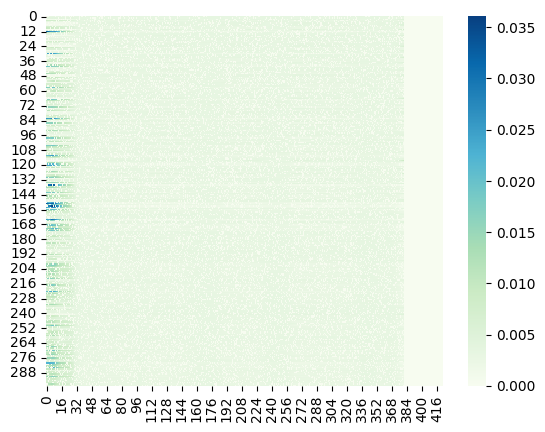

In [ ]:
e                   = 0
best_loss           = 20

checkpoint_root = os.path.join(MODEL_ROOT, "checkpoints-basic-transformer2")
os.makedirs(checkpoint_root, exist_ok=True)

if USE_WANDB:
    wandb.watch(model, log="all")

checkpoint_best_loss_model_filename     = 'checkpoint-best-loss-model.pth'
checkpoint_last_epoch_filename          = 'checkpoint-epoch-'
best_loss_model_path                    = os.path.join(checkpoint_root, checkpoint_best_loss_model_filename)

if RESUME_LOGGING:
    # change if you want to load best test model accordingly
    checkpoint = torch.load(wandb.restore(checkpoint_best_loss_model_filename, run_path=""+run_id).name)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    e = checkpoint['epoch']

    print("Resuming from epoch {}".format(e+1))
    print("Epochs left: ", config['epochs']-e)
    print("Optimizer: \n", optimizer)

torch.cuda.empty_cache()
gc.collect()

epochs = config["epochs"]
for epoch in range(e, epochs):

    print("\nEpoch {}/{}".format(epoch+1, config["epochs"]))

    curr_lr = float(optimizer.param_groups[0]["lr"])

    train_loss, train_perplexity, attention_weights = train_model(model, train_loader, optimizer)

    print("\nEpoch {}/{}: \nTrain Loss {:.04f}\t Train Perplexity {:.04f}\t Learning Rate {:.04f}".format(
        epoch + 1, config["epochs"], train_loss, train_perplexity, curr_lr))

    if (epoch % 2 == 0):    # validate every 2 epochs to speed up training
        levenshtein_distance = validate_fast(model, val_loader)
        print("Val Fast Levenshtein Distance {:.04f}".format(levenshtein_distance))

        if USE_WANDB: wandb.log({"train_loss"     : train_loss,
                "train_perplexity"  : train_perplexity,
                "learning_rate"     : curr_lr,
                "val_distance"      : levenshtein_distance})

    else:
        if USE_WANDB: wandb.log({"train_loss"     : train_loss,
                "train_perplexity"  : train_perplexity,
                "learning_rate"     : curr_lr})

    # plotting the encoder-nearest and decoder-nearest attention weights
    attention_keys = list(attention_weights.keys())

    attention_weights_decoder_self       = attention_weights[attention_keys[0]][0].cpu().detach().numpy()
    attention_weights_decoder_cross      = attention_weights[attention_keys[-1]][0].cpu().detach().numpy()

    # saving the cross-attention weights
    save_attention_plot(attention_weights_decoder_cross, epoch+100, checkpoint_root + '/')

    # plot_attention_weights((attention_weights[attention_keys[0]][0]).cpu().detach().numpy())
    # plot_attention_weights(attention_weights[attention_keys[-1]][0].cpu().detach().numpy())

    if config["scheduler"] == "ReduceLR":
        scheduler.step(levenshtein_distance)
    else:
        scheduler.step()

    ### Highly Recommended: Save checkpoint in drive and/or wandb if accuracy is better than your current best
    epoch_model_path = os.path.join(checkpoint_root, (checkpoint_last_epoch_filename + str(epoch) + '.pth'))
    save_model(model, optimizer, scheduler, ['train_loss', train_loss], epoch, epoch_model_path)
    ## wandb.save(epoch_model_path) ## Can't save on wandb for all epochs, may blow up storage

    print("Saved epoch model")

    if best_loss >= train_loss:
        best_loss = train_loss
        save_model(model, optimizer, scheduler, ['train_loss', train_loss], epoch, best_loss_model_path)
        # wandb.save(best_loss_model_path)
        print("Saved best training model")

### Finish your wandb run
if USE_WANDB: run.finish()

In [ ]:
validate_full(model, val_loader)

Val:   9%|▉         | 1/11 [01:45<17:39, 105.92s/it, running_distance=478.4727]


Ground Truth :  WE RANGE WIDER LAST LONGER AND ESCAPE MORE AND MORE FROM INTENSITY TOWARDS UNDERSTANDING
Prediction   :  AND THE SAID THE STRANGE OF THE STRANGE OF THE SAID THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE SAID THE STRANGE OF THE STRANGE OF THE SAID THE STRANGE OF THE SAID THE STRANGE OF THE SAID THE SAID THE SAID THE SAID THE SAID THE SAID THE STREE STREE STRE S STR OOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOUG THE S T T T THE T T T T T T T T T T THE T T THE T THE T T T T T T THE T T T T T T T T THE T T T T T THE T THE T THE T T THE T T T THE T THE THE THE THE T THE THE THE THE THE THE THE


Val:  18%|█▊        | 2/11 [03:29<15:41, 104.60s/it, running_distance=478.8965]


Ground Truth :  NOW HIS MIDDLE HORSE WAS BEING ALMOST DRAGGED BY THE OTHER TWO
Prediction   :  AND THE SAID THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE SAID THE STRANGE OF THE STRANGE OF THE STRANGE OF THE SAID THE STRANGE OF THE STRANGE OF THE SAID THE STRANGE OF THE SAID THE STRANGE OF THE STRANGE OF THE SAID THE SAID THE SAID THE SAID THE SAID THE STIME TRE S TRE ON ON THE THE T OUR OOUR THE THE THE T THE THE THE THE THE THE THE STHE THE THE THE THE TRE TRE THE TRE THE T THE THE TRE THE THE THE TROUNOURE OURE T OURE THE T THE THE T OURE T OURE OUR ON ON THE ON OON THE OUGUR OUR ON THE OOON THE THE OU


Val:  27%|██▋       | 3/11 [05:18<14:10, 106.36s/it, running_distance=477.7969]

...


Ground Truth :  HIS OWN SKIN HAD SIZZLED UNDER THE RED HOT BRAND HE MURMURED SOFTLY
Prediction   :  AND THE SAID THE STRANGE OF THE STRANGE OF THE SAID THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE SAID THE STRANGE OF THE SAID THE STRANGE OF THE SAID THE SAID THE SAID THE SAID THE SAID THE SAID THE STIME STRE S OFIME ON T THE T T OURE OOOUR THE S ONOWANOUN THE THE THE THE THE T THE THE THE THE THE THE T THE THE THE THE THE THE THE T THE THE T T T T TRE T T OURE T ONE T T T T T THE T ON THE THE ON T ON THE T THE THE THE ON OUR OOUR THE THE ON THE THE T


Val:  91%|█████████ | 10/11 [17:22<01:42, 102.59s/it, running_distance=480.0203]


Ground Truth :  SHE ASKED DIRECTLY IF HER FATHER WAS DEAD
Prediction   :  AND THE SAID THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE SAID THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE SAID THE STRANGE OF THE SAID THE STRANGE OF THE SAID THE SAID THE SAID THE SAID THE SAID THE SAID THE STIME TRE S TRE ON ON THE THE T OUR OOUR THE THE THE T THE THE THE THE THE THE THE STHE THE THE THE THE TRE TRE THE TRE THE T THE THE TRE THE THE THE TRE OUR T OURE T OURE T T T THE THE T ON THE OURE OURE ON THE THE THE THE OUSE OURE OUR THE THE THE THE OUR



Ground Truth :  THOU LIKE ARCTURUS STEADFAST IN THE SKIES WITH TARDY SENSE GUIDEST THY KINGDOM FAIR BEARING ALONE THE LOAD OF LIBERTY
Prediction   :  AND THE SAID THE STRANGE OF THE STRANGE OF THE SAID THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE STRANGE OF THE SAID THE STRANGE OF THE STRANGE OF THE SAID THE SAID THE SAID THE STRANGE OF THE STRANGE OF THE SAID THE SAID THE SAID THE SAID THE SAID THE STREE STREEE STR S STRE OOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOUG THE S T T T THE T THE T THE T T T T T THE T THE T T T THE T T T T THE T T T T T T T T THE T T T T T THE T THE T THE T T THE T T T THE T THE THE THE THE T THE THE THE THE THE THE THE


479.116368006993

## Testing

In [ ]:
model.eval()

# progress bar
batch_bar = tqdm(total=len(test_loader), dynamic_ncols=True, leave=False, position=0, desc="Test", ncols=5)

all_predictions = []

for i, data in enumerate(test_loader):
    inputs, inputs_lengths = data
    inputs                 = inputs.to(device)

    with torch.inference_mode():
        greedy_predictions = model.recognize(inputs, inputs_lengths)

    greedy_predictions = greedy_predictions.detach().cpu().numpy()

    for batch_idx in range(greedy_predictions.shape[0]):
        pred_sliced = indices_to_chars(greedy_predictions[batch_idx], vocab= VOCAB)
        pred_string = ''.join(pred_sliced)
        all_predictions.append(pred_string)

    batch_bar.update()

Test: 100%|██████████| 11/11 [17:07<00:00, 75.78s/it]

In [ ]:
# %cd /content/
df = pd.DataFrame({
    "index" : list(range(len(all_predictions))),
    "label" : all_predictions
})

df.to_csv("/content/gdrive/MyDrive/model/submission_p1_1.csv", index=False)

In [ ]:
# TODO Sumbit predictions to Kaggle

# PART #2 Full Transformer (Encoder-Decoder)

Using an LSTM encoder helps to capture some dependencies in the input sequence which helps the transformer decoder to decode. However, we can do more than that. The transformer encoder plays a crucial role by processing the input sequence into a high-dimensional space, capturing complex relationships between elements. It uses self-attention to understand the context around each feature, enabling the model to grasp subtle nuances and dependencies, crucial for our speech recognition task and improving performance.

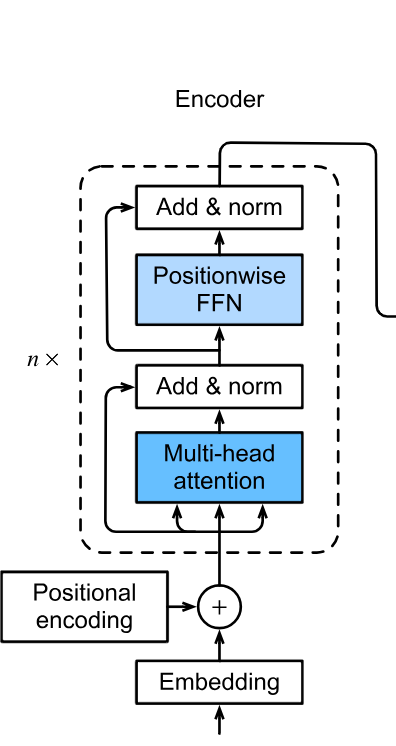

Tips in completing this section

* We will use the LSTM Encoder as input embedding.
* How many multi-head attention modules do we have.
* Can you seperate the encoder layer from the whole encoder architecture ?
* How do  we implement skip  connections
* How many layer norms do we have ?

In [ ]:
class EncoderLayer(torch.nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        # @TODO: fill in the blanks appropriately (given the modules above)
        self.mha = MultiHeadAttention(num_heads, d_model, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)

        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)


    def forward(self, inp):

        # Multi-Head Attention
        #   (1) perform Multi-Head Attention on inp
        attn, attn_weights_block = self.mha(inp, inp, inp)


        # Skip (Residual) Connection
        #   (1) perform dropout
        #   (2) add the input as a skip connection
        attn = inp + self.dropout1(attn)


        # Layer Normalization
        #   (1) call layernorm on this resulting value
        attn = self.layernorm1(attn)


        # Feed Forward Network
        #   (1) apply feed forward layer
        ffn_output = self.ffn(attn)


        # Skip (Residual) Connection
        #   (1) perform dropout
        #   (2) add the output of the first layernorm as a skip connection
        ffn_output = self.dropout2(ffn_output) + attn


        # Layer Normalization
        #   (1) call layernorm on this resulting value
        ffn_output = self.layernorm2(ffn_output)


        return ffn_output, attn_weights_block

In [ ]:
class Encoder(torch.nn.Module):
    def __init__(self, input_dim, num_layers, d_model, num_heads, d_ff, dropout=0.1):
        super(Encoder, self).__init__()

        # @TODO: fill in the blanks appropriately (given the modules above and P1 setup)
        self.embedding = CNN_LSTM_Enocder(input_dim, 256, dropout)
        self.projection =  nn.Linear(1024, d_model)
        self.pos_encoding = PositionalEncoding(d_model)

        # concatenating all num_layers EncoderLayer blocks
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.dropout = nn.Dropout(dropout)
        self.layernorm = nn.LayerNorm(d_model)

    def forward(self, x, input_lengths):

        # apply the CNN-LSTM Encoder (embedding)
        x, enc_lens = self.embedding(x, input_lengths)

        # adding projection layer to change dimension of encoder_outputs to match d_model
        x = self.projection(x)


        # apply Positional Encoding on these extracted features
        x = self.pos_encoding(x)


        # apply dropout as regularization technique
        x = self.dropout(x)


        # passing inputs through Transformer Encoder blocks
        for layer in self.enc_layers:
            x, _ = layer(x)

        x = self.layernorm(x)

        return x, enc_lens

In [ ]:
class DecoderLayer(torch.nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        self.mha1 = MultiHeadAttention(num_heads, d_model, dropout)
        self.mha2 = MultiHeadAttention(num_heads, d_model, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)

        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.layernorm3 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)


    def forward(self, padded_targets, enc_output, enc_input_lengths, dec_enc_attn_mask, pad_mask, slf_attn_mask):

        # Masked Multi-Head Attention
        #   (1) apply MHA with the lookahead mask
        attn1, attn_weights_block1 = self.mha1(padded_targets, padded_targets, padded_targets, slf_attn_mask)

        # print(padded_targets.shape, enc_output.shape, enc_output.shape, slf_attn_mask.shape)
        # padded_targets = create_mask_2(padded_targets)
        # raise EOFError

        # Skip (Residual) Connections
        #   (1) perform dropout on padded attention output
        #   (2) add the true outputs (padded_targets) as a skip connection
        attn1 = self.dropout1(attn1) + padded_targets



        # Layer Normalization
        #   (1) call layernorm on this resulting value
        attn1 = self.layernorm1(attn1)


        # Masked Multi-Head Attention on Encoder Outputs and Targets
        #   (1) apply MHA with the self-attention mask
        attn2, attn_weights_block2 = self.mha2(attn1, enc_output, enc_output, dec_enc_attn_mask)



        # Skip (Residual) Connections
        #   (1) perform dropout on this second padded attention output
        #   (2) add the output of first MHA block as a skip connection
        attn2 = self.dropout2(attn2) + attn1


        # Layer Normalization
        #   (1) call layernorm on this resulting value
        attn2 = self.layernorm2(attn2)


        # Feed Forward Network
        #   (1) pass through the FFN
        ffn_output = self.ffn(attn2)


        # Skip (Residual) Connections
        #   (1) perform dropout on the output
        #   (2) add the output of second MHA block as a skip connection
        ffn_output = self.dropout3(ffn_output) + attn2


        # apply Layer Normalization on this resulting value
        ffn_output = self.layernorm3(ffn_output)


        # return the network output and both attention weights (for mha1 and mha2)
        # @NOTE: returning the self attention weights first
        return attn_weights_block1, attn_weights_block2, ffn_output

In [ ]:
class Decoder(torch.nn.Module):
    def __init__(self, num_layers, d_model, num_heads, d_ff, dropout,
            target_vocab_size, max_seq_length, eos_token, sos_token, pad_token):
        super().__init__()

        self.EOS_TOKEN = eos_token
        self.SOS_TOKEN = sos_token
        self.PAD_TOKEN = pad_token

        self.max_seq_length = max_seq_length
        self.num_layers = num_layers

        # use torch.nn.ModuleList() with list comprehension looping through num_layers
        # @NOTE: think about what stays constant per each DecoderLayer (how to call DecoderLayer)
        # @HINT: We've implemented this for you.

        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.target_embedding = nn.Embedding(target_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model)
        self.final_linear = nn.Linear(d_model, target_vocab_size)
        self.dropout = nn.Dropout(dropout)


    def forward(self, padded_targets, enc_output, enc_input_lengths):

        # create a padding mask for the padded_targets with <PAD_TOKEN>
        pad_mask = padded_targets.eq(self.PAD_TOKEN)

        # creating an attention mask for the future subsequences (look-ahead mask)
        # print(padded_targets.shape)
        slf_attn_mask_subseq = create_mask_2(padded_targets)

        # creating attention mask to ignore padding positions in the input sequence during attention calculation
        dec_enc_attn_mask = create_mask_3(enc_output, enc_input_lengths, padded_targets.size(1))


        # computing embeddings for the target sequence
        x = self.target_embedding(padded_targets)

        # computing Positional Encodings with the embedded targets and apply dropout
        x = self.positional_encoding(x)
        x = self.dropout(x)

        # passing through decoder layers
        # @NOTE: store your mha1 and mha2 attention weights inside a dictionary
        # @NOTE: you will want to retrieve these later so store them with a useful name
        attn_weights = {}
        for i in range(self.num_layers):
            attn_weights[f"mha1_{i}"], attn_weights[f"mha2_{i}"], x = self.dec_layers[i](
                x, enc_output, enc_input_lengths, dec_enc_attn_mask, pad_mask, slf_attn_mask_subseq
            )


        # linear layer (Final Projection) for next character prediction
        seq_out = self.final_linear(x)


        # return the network output and the dictionary of attention weights
        return seq_out, attn_weights

    def recognize_greedy_search(self, enc_outputs, enc_input_lengths):
        ''' passes the encoder outputs and its corresponding lengths through autoregressive network

            @NOTE: You do not need to make changes to this method.
        '''

        batch_size = enc_outputs.size(0)

        # start with the <SOS> token for each sequence in the batch
        target_seq = torch.full((batch_size, 1), self.SOS_TOKEN, dtype=torch.long).to(enc_outputs.device)

        finished = torch.zeros(batch_size, dtype=torch.bool).to(enc_outputs.device)

        for _ in range(self.max_seq_length):

            # preparing attention masks
            # filled with ones becaues we want to attend to all the elements in the sequence
            pad_mask = torch.ones_like(target_seq).float().unsqueeze(-1)  # (batch_size x i x 1)
            slf_attn_mask_subseq = create_mask_2(target_seq)

            x = self.positional_encoding(self.target_embedding(target_seq))

            for i in range(self.num_layers):
                block1, block2, x = self.dec_layers[i](
                    x, enc_outputs, enc_input_lengths, None, pad_mask, slf_attn_mask_subseq)

            seq_out = self.final_linear(x[:, -1])
            logits = torch.nn.functional.log_softmax(seq_out, dim=1)

            # selecting the token with the highest probability
            # @NOTE: this is the autoregressive nature of the network!
            next_token = logits.argmax(dim=-1).unsqueeze(1)

            # appending the token to the sequence
            target_seq = torch.cat([target_seq, next_token], dim=-1)

            # checking if <EOS> token is generated
            eos_mask = next_token.squeeze(-1) == self.EOS_TOKEN
            # or opration, if both or one of them is true store the value of the finished sequence in finished variable
            finished |= eos_mask

            # end if all sequences have generated the EOS token
            if finished.all(): break

        # remove the initial <SOS> token and pad sequences to the same length
        target_seq = target_seq[:, 1:]
        max_length = target_seq.size(1)
        target_seq = torch.nn.functional.pad(target_seq,
            (0, self.max_seq_length - max_length), value=self.PAD_TOKEN)

        return target_seq

In [ ]:
class FullTransformer(torch.nn.Module):
    def __init__(self, input_dim, enc_num_layers, dec_num_layers, enc_num_heads, dec_num_heads,
                 d_model, d_ff, target_vocab_size, eos_token, sos_token,
                 pad_token, enc_dropout=0.1, dec_dropout=0.1,trans_max_seq_length=550, mfcc_max_seq_length=3260):

        super(FullTransformer, self).__init__()

        self.encoder = Encoder(input_dim, enc_num_layers, d_model, enc_num_heads, d_ff, enc_dropout)
        self.decoder = Decoder(dec_num_layers, d_model, dec_num_heads, d_ff, dec_dropout, target_vocab_size, trans_max_seq_length, eos_token, sos_token, pad_token)

    def forward(self, padded_input, input_lengths, padded_target, target_lengths):
        # passing through Encoder
        encoder_output, encoder_lens = self.encoder(padded_input, input_lengths)


        # passing Encoder output and Attention masks through Decoder
        output, attention_weights = self.decoder(padded_target, encoder_output, encoder_lens)

        return output, attention_weights

    def recognize(self, inp, inp_len):
        """ sequence-to-sequence greedy search -- decoding one utterance at a time """

        encoder_output, encoder_lens = self.encoder(inp, inp_len)
        out = self.decoder.recognize_greedy_search(encoder_output, encoder_lens)

        return out

## Full Model Setup

In [ ]:
full_model = FullTransformer(
input_dim                   = config['input_dim'],
enc_num_layers              = config['enc_num_layers'],
dec_num_layers              = config['dec_num_layers'],
enc_num_heads               = config['enc_num_heads'],
dec_num_heads               = config['dec_num_heads'],

d_model                     = config['d_model'],
d_ff                        = config['d_ff'],

target_vocab_size           = len(VOCAB),
eos_token                   = EOS_TOKEN,
sos_token                   = SOS_TOKEN,
pad_token                   = PAD_TOKEN,

enc_dropout                 = config['enc_dropout'],
dec_dropout                 = config['dec_dropout'],

# decrease to a small number if you are just trying to implement the network
# we've computed the max length of the transcripts for you
trans_max_seq_length        = 550,
mfcc_max_seq_length         = 3260
).to(device)

In [ ]:
print(full_model)

FullTransformer(
  (encoder): Encoder(
    (embedding): CNN_LSTM_Enocder(
      (embedding): Sequential(
        (0): Conv1d(27, 54, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(54, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv1d(54, 108, kernel_size=(5,), stride=(1,), padding=(2,))
        (4): BatchNorm1d(108, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (blistm): LSTM(108, 256, batch_first=True, dropout=0.3, bidirectional=True)
      (pBLSTMs): Sequential(
        (0): pBLSTM(
          (blstm): LSTM(1024, 256, batch_first=True, bidirectional=True)
        )
        (1): LockedDropout()
        (2): pBLSTM(
          (blstm): LSTM(1024, 512, batch_first=True, bidirectional=True)
        )
        (3): LockedDropout()
      )
      (permute): PermuteBlock()
    )
    (projection): Linear(in_features=1024, out_features=512, bias=

In [ ]:
summary(full_model, input_data=(batch[0], batch[3], batch[1], batch[4]), device=device)

Layer (type:depth-idx)                                       Output Shape              Param #
FullTransformer                                              [256, 298, 31]            --
├─Encoder: 1-1                                               [256, 426, 512]           --
│    └─CNN_LSTM_Enocder: 2-1                                 [256, 426, 1024]          --
│    │    └─PermuteBlock: 3-1                                [256, 27, 1707]           --
│    │    └─Sequential: 3-2                                  [256, 108, 1707]          36,936
│    │    └─PermuteBlock: 3-3                                [256, 1707, 108]          --
│    │    └─LSTM: 3-4                                        [326946, 512]             749,568
│    │    └─Sequential: 3-5                                  [81645, 1024]             8,925,184
│    └─Linear: 2-2                                           [256, 426, 512]           524,800
│    └─PositionalEncoding: 2-3                               [256, 426, 51

## Loss, Optimizer, and Scheduler Definitions

In [ ]:
loss_func = nn.CrossEntropyLoss(ignore_index = PAD_TOKEN)
scaler = torch.amp.GradScaler()

In [ ]:
''' defining optimizer '''

if config["optimizer"] == "SGD":
  # feel free to change any of the initializations you like to fit your needs
  optimizer = torch.optim.SGD(full_model.parameters(),
                              lr=config["learning_rate_2"],
                              momentum=config["momentum"],
                              weight_decay=1E-4,
                              nesterov=config["nesterov"])

elif config["optimizer"] == "Adam":
  # feel free to change any of the initializations you like to fit your needs
  optimizer = torch.optim.Adam(full_model.parameters(),
                               lr=float(config["learning_rate_2"]),
                               weight_decay=1e-4)

elif config["optimizer"] == "AdamW":
  # feel free to change any of the initializations you like to fit your needs
  optimizer = torch.optim.AdamW(full_model.parameters(), lr=float(config["learning_rate_2"]),
                                betas=(0.9, 0.999),
                                eps=1e-9,
                                weight_decay=0.01)

''' defining scheduler '''

if config["scheduler"] == "ReduceLR":
  #Feel Free to change any of the initializations you like to fit your needs
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                factor=config["factor"], patience=config["patience"], min_lr=1E-8)

elif config["scheduler"] == "CosineAnnealing":
  #Feel Free to change any of the initializations you like to fit your needs
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,
                T_max = config["epochs"], eta_min=1E-8)

## Experiments


Epoch 1/100



Epoch 1/100: 
Train Loss 2.6053	 Train Perplexity 13.8449	 Learning Rate 0.0001


Val:   9%|▉         | 1/11 [01:46<17:44, 106.43s/it, running_distance=505.5586]


Ground Truth :  WE RANGE WIDER LAST LONGER AND ESCAPE MORE AND MORE FROM INTENSITY TOWARDS UNDERSTANDING
Prediction   :  HE THE THE THE THE THE THE THE THE THE THE THE THE AN THE THE THE THE THE THE THE THE THE THE THE AN THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE THE T


Val:  18%|█▊        | 2/11 [03:30<15:45, 105.04s/it, running_distance=505.3379]

...


Ground Truth :  SHE ASKED DIRECTLY IF HER FATHER WAS DEAD
Prediction   :  SHE HAS THE RECLEEY FOR FATHER WAS THAT THERE WAS DAND THE HAD THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE THE MAN THE WAS THE WAS THE WAS THE THE WAT THE THE THE THE THE THE HE WO THE HE THE HE HE THE WATHE HE HE THE WATHE THE THE WO WAD WAD THE HE HE HE HE HE HE WAD WAD WAD THE WAD WAD WAD WAD WAD THAD WAD WAD WAD THE THE THAD THE THAD THAD WAD WAD WAD WAD WAD THAD WAD WAD THATHATHAD T T T T T T T THATHAT T T



Ground Truth :  THOU LIKE ARCTURUS STEADFAST IN THE SKIES WITH TARDY SENSE GUIDEST THY KINGDOM FAIR BEARING ALONE THE LOAD OF LIBERTY
Prediction   :  THERE ALL I HARTERS STAND PASSSS IN THE SARES WITH THE CARRRRY SENS THAT IS BY CAME THE PARE THEIR NO LONG BUT THE LITTTLERY IT WAS A COULD AND THE THE THE HAD THE HAD THE HAD THE THE HAD THE HAD THE HAD THE HAD THE HAD THE HAD THE HAD THE HAD THE HAD THE HAD THE WAS AND THE HE WAD WAND THE THE THE HE THE HE WAD WAD THE HE WAD HE WAD WAD WAD HE HE HE WAD WAD THE THE WAD WAD THE WAD THE HE THE HE HE WAD WAD WAD THE WAD WAD WAD WAD THE THAD WAD WAD THAD THE THE THE T THE THE WAD WAD WAD WAD WAD THAD THAD WAD THAD THE THE T T T T T T T THAD THE T 
Val fast Levenshtein Distance 473.5852


Saved epoch model

Epoch 100/100



Epoch 100/100: 
Train Loss 1.2214	 Train Perplexity 3.4307	 Learning Rate 0.0000
Saved epoch model


learning_rate,█████████▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_perplexity,█▆▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_distance,███▆▄▄▄▃▄▄▄▄▄▃▄▃▃▃▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
learning_rate,0.0
train_loss,1.22142
train_perplexity,3.43069
val_distance,473.58518


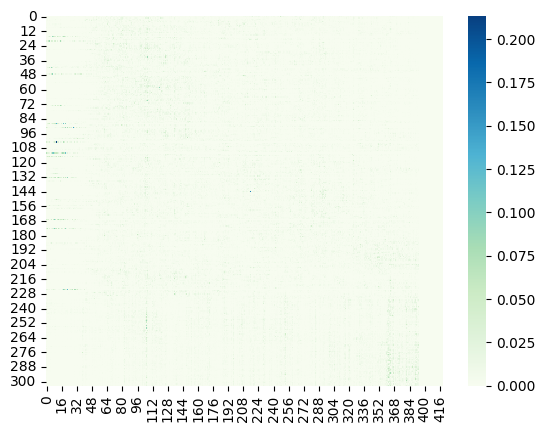

In [ ]:
###  Now let's train the encoder to master the encoder input ranges
e                   = 0
best_loss           = 10.0

checkpoint_root = os.path.join("/content/model/", 'checkpointsfull3')
os.makedirs(checkpoint_root, exist_ok=True)
if USE_WANDB: wandb.watch(full_model, log="all")

checkpoint_best_loss_model_filename     = 'checkpoint-best-loss-modelfull.pth'
checkpoint_last_epoch_filename          = 'checkpoint-epochfull-'
best_loss_model_path                    = os.path.join("/content/drive/MyDrive/model/", checkpoint_best_loss_model_filename)

RESUME_LOGGING = False

if RESUME_LOGGING:
    # change if you want to load best test model accordingly
    checkpoint = torch.load(os.path.join(MODEL_ROOT, "checkpointsfull", "checkpoint-epochfull-46.pth"))

    full_model.load_state_dict(checkpoint['model_state_dict'])
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    e = checkpoint['epoch']

    print("Resuming from epoch {}".format(e+1))
    print("Epochs left: ", config['epochs']-e)
    print("Optimizer: \n", optimizer)

torch.cuda.empty_cache()
gc.collect()

epochs = config["epochs"]
for epoch in range(e, epochs):

    print("\nEpoch {}/{}".format(epoch+1, config["epochs"]))

    curr_lr = float(optimizer.param_groups[0]["lr"])

    train_loss, train_perplexity, attention_weights = train_model(full_model, train_loader, optimizer)

    print("\nEpoch {}/{}: \nTrain Loss {:.04f}\t Train Perplexity {:.04f}\t Learning Rate {:.04f}".format(
        epoch + 1, config["epochs"], train_loss, train_perplexity, curr_lr))

    if (epoch % 2 == 0):    # validate every 2 epochs to speed up training
        levenshtein_distance = validate_full(full_model, val_loader)
        print("Val fast Levenshtein Distance {:.04f}".format(levenshtein_distance))

        if USE_WANDB: wandb.log({"train_loss"     : train_loss,
                "train_perplexity"  : train_perplexity,
                "learning_rate"     : curr_lr,
                "val_distance"      : levenshtein_distance})

    else:
        if USE_WANDB: wandb.log({"train_loss"     : train_loss,
                "train_perplexity"  : train_perplexity,
                "learning_rate"     : curr_lr})

    # plotting the encoder-nearest and decoder-nearest attention weights
    attention_keys = list(attention_weights.keys())

    # plot_attention_weights((attention_weights[attention_keys[0]][0]).cpu().detach().numpy())
    # plot_attention_weights(attention_weights[attention_keys[-1]][0].cpu().detach().numpy())

    attention_weights_decoder_self       = attention_weights[attention_keys[0]][0].cpu().detach().numpy()
    attention_weights_decoder_cross      = attention_weights[attention_keys[-1]][0].cpu().detach().numpy()
    save_attention_plot(attention_weights_decoder_cross, epoch, folder=checkpoint_root + '/')

    if config["scheduler"] == "ReduceLR":
        scheduler.step(levenshtein_distance)
    else:
        scheduler.step()

    ### Highly Recommended: Save checkpoint in drive and/or wandb if accuracy is better than your current best
    epoch_model_path = os.path.join(checkpoint_root, (checkpoint_last_epoch_filename + str(epoch) + '.pth'))
    save_model(full_model, optimizer, scheduler, ['train_loss', train_loss], epoch, epoch_model_path)
    ## wandb.save(epoch_model_path) ## Can't save on wandb for all epochs, may blow up storage

    print("Saved epoch model")

    # the first time we add the transformer encoder block, we freeze all other weights
    #   except the transformer encoder weights and train this partially-frozen model
    #   for about 3 epochs to weight initialize the transformer encoder weights.
    #   This speeds up convergence of the entire network.
    if epoch == 3:
        print("Unfreezing the Transformers")
        for param in full_model.encoder.embedding.parameters():
            param.requires_grad = True

        for param in full_model.encoder.projection.parameters():
            param.requires_grad = True

        for param in full_model.decoder.parameters():
            param.requires_grad = True

    if train_loss <= best_loss:
        best_loss = train_loss
        save_model(full_model, optimizer, scheduler, ['train_loss', train_loss], epoch, best_loss_model_path)
        # wandb.save(best_loss_model_path)
        print("Saved best training model")

### Finish your wandb run
run.finish()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
full_model.load_state_dict(torch.load(os.path.join("/content/drive/MyDrive/model/checkpoint-best-loss-modelfull.pth"))['model_state_dict'])

full_model.eval()

FullTransformer(
  (encoder): Encoder(
    (embedding): CNN_LSTM_Enocder(
      (embedding): Sequential(
        (0): Conv1d(27, 54, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(54, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv1d(54, 108, kernel_size=(5,), stride=(1,), padding=(2,))
        (4): BatchNorm1d(108, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (blistm): LSTM(108, 256, batch_first=True, dropout=0.3, bidirectional=True)
      (pBLSTMs): Sequential(
        (0): pBLSTM(
          (blstm): LSTM(1024, 256, batch_first=True, bidirectional=True)
        )
        (1): LockedDropout()
        (2): pBLSTM(
          (blstm): LSTM(1024, 512, batch_first=True, bidirectional=True)
        )
        (3): LockedDropout()
      )
      (permute): PermuteBlock()
    )
    (projection): Linear(in_features=1024, out_features=512, bias=

In [ ]:
validate_full(full_model, val_loader)

Val:   9%|▉         | 1/11 [01:45<17:36, 105.67s/it, running_distance=476.6914]


Ground Truth :  WE RANGE WIDER LAST LONGER AND ESCAPE MORE AND MORE FROM INTENSITY TOWARDS UNDERSTANDING
Prediction   :  THE RANGE WATER WAS THE LONGER AND THE STEEP MORE AND SPEAK MORE FROM AND CANSITY PORCE ON THE RESTANDING THE COULD HAVE THE COULD HAVE THE COULD HAVE THE COULD HAVE THE CAN THE CAN THE CAN THE COULD AND THE CAN THE CAN THE THE THE THE THE THE THE OTHER THE WAS THE WAS THE THE WAT THE THE THE THE HE THE THE THE HE THE THE THE HE HE THE WO WO HE HE HE HAD WO THE THE WO WO WO THE WO HE HAD HE HE HAD HE WAD WAD HAD HAD WAD WAD THAD THAD THAD WAD WAD THAD THAD THAD THE THAD THAD WAD THAD WAD THAD THAD THAD WAD THAD THAD THAD THAD THAD THAD THAD THA


Val:  18%|█▊        | 2/11 [03:29<15:39, 104.37s/it, running_distance=475.6816]


Ground Truth :  NOW HIS MIDDLE HORSE WAS BEING ALMOST DRAGGED BY THE OTHER TWO
Prediction   :  NO WAS NOT PORSE WAS BE NOT ONE OF STRAND BY THE EVER SHE WAS A SHE WAS A COULD AND THE CAN THE CAN THE COULD HAVE THE COULD HAVE THE COULD AND THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE THE THE THE THE THE THE THE OTHE OF THE HE HAD HE WAD THE THE HE THE THE THE THE THE THAD THE THE THE THE THE THE THE HE THE THE THE THE THE THE THE THAD HE THE THAD THE WO THE THAD THAD WO THE THAD THAD THAD THAD THAD THE THE THE THE THAD THAD THE THE THE THE THAD THAD THAD THAD THE THAD THAD THAD THAD THAD THAD


Val:  27%|██▋       | 3/11 [05:17<14:09, 106.15s/it, running_distance=473.7174]

...


Ground Truth :  HIS OWN SKIN HAD SIZZLED UNDER THE RED HOT BRAND HE MURMURED SOFTLY
Prediction   :  IS ONCE STEEM AND SILL ON THE RECT OUT REAR COMMMER AS OFFFILY AND THE COULD HAVE THE COULD HAVE THE COULD HAVE THE COULD HAVE THE COULD HAVE THE COULD HAVE THE COULD HAVE THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE THE THE THE HAD THE THE HAD THE HAD THE THE HE HE HAD HE HAD THE T THE THE THE THAD THAD THE THE THE THE THE THE THE THE THE THEAD THEAD THEAD THEAD THEAD THEAD THE THE THE THAD THE THEAD THE THAD THAD THAD THAD THEAD THE THE THE THAD THAD THE THE THE T THE THAD THAD THAD THAD THE THAD THAD T THAD T THAD THAD


Val:  91%|█████████ | 10/11 [17:22<01:42, 102.60s/it, running_distance=475.2156]


Ground Truth :  SHE ASKED DIRECTLY IF HER FATHER WAS DEAD
Prediction   :  SHE HAS THE RECLEY OF HER FATHER WAS THAT THERE WAS THAT I SHAD THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE CAN THE THE MAN THE THE MAN THE WAS THE THE WAN THE THE THE THE THE THE THE THE THE THE THE THE THE THE WO THE THE THE THE THE THE THE WO WO THE THE THE THE THE THE THE WO WO THE THE THE WO WO THE THE THE THE WAD WO THE THE THE THE THE THE THE WAD THE WATHE THE THANO THE WO THE THE THE THANO THATHE THE THE THE TH



Ground Truth :  THOU LIKE ARCTURUS STEADFAST IN THE SKIES WITH TARDY SENSE GUIDEST THY KINGDOM FAIR BEARING ALONE THE LOAD OF LIBERTY
Prediction   :  THERE ALL I HARTERS STAND PASSSS IN THE SAYS WITH THE CARRRRY SENS THAT IS BY CAME THE PARE THEIR NO LONG BUT THE LITTTLERY IT WAS A COULD AND THE THE THE THE THE HAD THE HAD THE COULD HAVE THE COULD HAVE THE COULD HER THE WAS AND THE WAS AND THE WAS AND THE WAS AND THE WAS THE AND THE THE WAN THE THE THE THE WE WE THE THE WAD WANO THE WE WAD THE THE THE WANO THE THE WANO WANO THE THE THE THE THE THE WANO WANO THE THE WO THE THE THE THE WAD WAD WATHE THE THE THE THE THE THE WAD THE WAD WANO THE THE THE WANO THE THE THE THE THE THE THE THE THE T


474.759277654164

## Testing

In [ ]:
#Load best:
full_model.load_state_dict(torch.load(os.path.join("/content/drive/MyDrive/model/checkpoint-best-loss-modelfull.pth"))['model_state_dict'])

full_model.eval()

# progress bar
batch_bar = tqdm(total=len(test_loader), dynamic_ncols=True, leave=False, position=0, desc="Test", ncols=5)

all_predictions = []

for i, data in enumerate(test_loader):
    inputs, inputs_lengths = data
    inputs                 = inputs.to(device)

    with torch.inference_mode():
        greedy_predictions = full_model.recognize(inputs, inputs_lengths)

    greedy_predictions = greedy_predictions.detach().cpu().numpy()

    for batch_idx in range(greedy_predictions.shape[0]):
        pred_sliced = indices_to_chars(greedy_predictions[batch_idx], vocab= VOCAB)
        pred_string = ''.join(pred_sliced)
        all_predictions.append(pred_string)

    batch_bar.update()

Test: 100%|██████████| 11/11 [17:10<00:00, 75.97s/it]

In [ ]:
# %cd /content/
df = pd.DataFrame({
    "index" : list(range(len(all_predictions))),
    "label" : all_predictions
})

df.to_csv("/content/drive/MyDrive/model/submission_full_2.csv", index=False)

In [ ]:
# !kaggle competitions submit -c hw4p2-sp24 -f improved.csv -m "It's been a ride :)"

# Part #3 (Improving your Model)
* Think of the input embedding, can you have something better than just an CNN-LSTM? Hint: HW3P2 might perform better.
* Think about the transformer encoder parameter, what about number of heads and number of layers, can this help?
* What about the decoder parameters what can  we improve there?
* We trained using an incremental training technique, can we use this technique to add more layers?

**Good Luck!!**

Length Normalization because Beam Search  short

The encoder consists of three components:

1. Convolutional subsampling layers to reduce sequence length.
2. Residual CNN blocks for local acoustic feature extraction.
3. BiLSTM and pyramidal BLSTM layers for long-range temporal modeling.

In [ ]:
class ConvSubsampling(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, 2*input_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(2*input_dim),
            nn.ReLU(),

            nn.Conv1d(2*input_dim, 4*input_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(4*input_dim),
            nn.ReLU()
        )

    def forward(self, x, x_lens):

        # (B,T,F) → (B,F,T)
        x = x.transpose(1,2)

        x = self.conv(x)

        # (B,C,T) → (B,T,C)
        x = x.transpose(1,2)

        x_lens = x_lens // 4

        return x, x_lens

In [ ]:
class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
            nn.ReLU(),

            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels)
        )

        self.relu = nn.ReLU()

    def forward(self, x):

        residual = x

        x = self.conv(x)

        x = x + residual

        x = self.relu(x)

        return x

In [ ]:
class CNN_LSTM_Encoder(nn.Module):

    def __init__(self, input_size, encoder_hidden_size, enc_dropout=0.2):
        super().__init__()

        # Conv subsampling
        self.subsample = ConvSubsampling(input_size)

        # CNN frontend
        cnn_channels = 4 * input_size

        self.cnn = nn.Sequential(
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),

            ResidualBlock(cnn_channels),
            ResidualBlock(cnn_channels)
        )

        # BiLSTM
        self.bilstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=encoder_hidden_size,
            bidirectional=True,
            batch_first=True,
            dropout=enc_dropout
        )

        # pBLSTM
        self.pBLSTMs = nn.Sequential(
            pBLSTM(2 * encoder_hidden_size, encoder_hidden_size),
            LockedDropout(enc_dropout),

            pBLSTM(2 * encoder_hidden_size, encoder_hidden_size),
            LockedDropout(enc_dropout)
        )

    def forward(self, x, x_lens):

        # Conv subsampling
        x, x_lens = self.subsample(x, x_lens)

        # (B,T,C) → (B,C,T)
        x = x.transpose(1,2)

        x = self.cnn(x)

        # (B,C,T) → (B,T,C)
        x = x.transpose(1,2)

        x_packed = pack_padded_sequence(
            x,
            x_lens,
            batch_first=True,
            enforce_sorted=False
        )

        x_packed, _ = self.bilstm(x_packed)

        x_packed = self.pBLSTMs(x_packed)

        encoder_outputs, encoder_lens = pad_packed_sequence(
            x_packed,
            batch_first=True
        )

        return encoder_outputs, encoder_lens

### Self-Attention with Relative Position Representations ###

reference: https://github.com/AliHaiderAhmad001/Self-Attention-with-Relative-Position-Representations/blob/main/Self_Attention_with_Relative_Position_Representations.ipynb

In [ ]:
class RelativePosition(nn.Module):

    def __init__(self, head_dim, k):
        super().__init__()

        self.k = k

        self.embeddings = nn.Embedding(2 * k + 1, head_dim)

    def forward(self, q_len, k_len):

        device = self.embeddings.weight.device

        q_pos = torch.arange(q_len, device=device)
        k_pos = torch.arange(k_len, device=device)
        # dist[i, j] = j - i
        dist = k_pos[None, :] - q_pos[:, None]

        dist = torch.clamp(dist, -self.k, self.k)

        dist = dist + self.k
        # (q_len , k_len , head_dim)
        return self.embeddings(dist)

In [ ]:
class RelationAwareAttentionHead(nn.Module):
    """
    Relation-aware attention head implementation.

    Args:
        hidden_size (int): Hidden size for the model (embedding dimension).
        head_dim (int): Dimensionality of the attention head.
        k_bias_matrix (torch.Tensor): Matrix for relative position attention in query-key interaction.
        v_bias_matrix (torch.Tensor): Matrix for relative position attention in query-value interaction.

    Attributes:
        query_weights (nn.Linear): Linear layer for query projection.
        key_weights (nn.Linear): Linear layer for key projection.
        value_weights (nn.Linear): Linear layer for value projection.
    """

    def __init__(self, temperature, attn_dropout=0.1):
        """
        Initializes the RelationAwareAttentionHead.

        Args:
            k_bias_matrix (torch.Tensor): Matrix for relative position attention in query-key interaction.
            v_bias_matrix (torch.Tensor): Matrix for relative position attention in query-value interaction.
        """
        super().__init__()

        self.temperature = temperature
        self.dropout = nn.Dropout(attn_dropout)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, q, k, v, k_bias_matrix, v_bias_matrix, mask=None):
        """
        Applies attention mechanism to the input query, key, and value tensors.

        Args:
            query (torch.Tensor): Query tensor.
            key (torch.Tensor): Key tensor.
            value (torch.Tensor): Value tensor.
            mask (torch.Tensor): Optional mask tensor.

        Returns:
            torch.Tensor: Updated value embeddings after applying attention mechanism.
        """

        # Self-Attention scores
        attn_1 = torch.matmul(q, k.transpose(-2, -1)) # Q*K^T:(b_s, n_t, n_t)

        # Relative Position Attention scores
        # (len_q, len_k, d_k) -> (1, len_q, len_k, d_k)
        k_bias_matrix = k_bias_matrix.unsqueeze(0)

        # q: (B*H, Lq, d_k)
        attn_2 = torch.einsum("bld,lrd->blr", q , k_bias_matrix.squeeze(0).to(attn_1.device))# (b_s, n_t, n_t)

        # Relation-aware Self-Attention scores
        attn: torch.Tensor = (attn_1 + attn_2) / self.temperature

        if mask is not None:
            mask_value = -1e+30 if attn.dtype == torch.float32 else -1e+4
            attn = attn.masked_fill(mask.to(attn.device), mask_value)

        attn = self.softmax(attn)

        attn = self.dropout(attn)

        # Weighted sum of values
        values_1 = torch.matmul(attn, v) # (b_s, n_t, head_dim)

        # Relative Position Representation for values
        values_2 = torch.matmul(attn.permute(1, 0, 2), v_bias_matrix.to(attn.device)).transpose(0, 1) # (b_s, n_t, head_dim)

        # Relation-aware values
        n_value  = values_1 + values_2
        return n_value, attn


In [ ]:
class RelationAwareMultiHeadAttention(nn.Module):
    """
    Multi-head attention layer implementation.

    Args:
        hidden_size (int): Hidden size for the model (embedding dimension).
        num_heads (int): Number of attention heads.
        k (int): Clipping distance for relative position embeddings.
        seq_len (int): Length of the input sequences.

    Attributes:
        hidden_size (int): Hidden size for the model (embedding dimension).
        num_heads (int): Number of attention heads.
        head_dim (int): Dimensionality of each attention head.
        relative_position_k (RelativePosition): Instance of RelativePosition for query-key relative positions.
        relative_position_v (RelativePosition): Instance of RelativePosition for query-value relative positions.
        k_bias_matrix (torch.Tensor): Matrix for relative position attention in query-key interaction.
        v_bias_matrix (torch.Tensor): Matrix for relative position attention in query-value interaction.
        attention_heads (nn.ModuleList): List of RelationAwareAttentionHead layers.
        fc (nn.Linear): Fully connected layer for final projection.
    """

    def __init__(self, hidden_size, num_heads, k, max_seq_length, dropout=0.2):
        """
        Initializes the RelationAwareMultiHeadAttention layer.

        Args:
            hidden_size (int): Hidden size for the model (embedding dimension).
            num_heads (int): Number of attention heads.
            k (int): Clipping distance for relative position embeddings.
            seq_len (int): Length of the input sequences.
        """
        super().__init__()
        self.d_model = hidden_size
        self.num_heads = num_heads
        self.d_k = hidden_size // num_heads
        self.d_v = hidden_size // num_heads

        self.w_qs = nn.Linear(self.d_model, num_heads * self.d_k)
        self.w_ks = nn.Linear(self.d_model, num_heads * self.d_k)
        self.w_vs = nn.Linear(self.d_model, num_heads * self.d_v)

        nn.init.normal_(self.w_qs.weight, mean=0, std=np.sqrt(2.0 / (self.d_model + self.d_k)))
        nn.init.normal_(self.w_ks.weight, mean=0, std=np.sqrt(2.0 / (self.d_model + self.d_k)))
        nn.init.normal_(self.w_vs.weight, mean=0, std=np.sqrt(2.0 / (self.d_model + self.d_v)))

        self.relative_position_k = RelativePosition(self.d_k, k)
        self.relative_position_v = RelativePosition(self.d_v, k)

        self.attention = RelationAwareAttentionHead(
            temperature=np.power(self.d_v, 0.5),
            attn_dropout=dropout
        )

        self.fc = nn.Linear(num_heads * self.d_v, hidden_size)
        nn.init.xavier_normal_(self.fc.weight)

        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        """
        Applies multi-head attention mechanism to the input query, key, and value tensors.

        Args:
            query (torch.Tensor): Query tensor.
            key (torch.Tensor): Key tensor.
            value (torch.Tensor): Value tensor.
            mask (torch.Tensor): Optional mask tensor.

        Returns:
            torch.Tensor: Updated hidden state after applying multi-head attention mechanism.
        """
        d_k, d_v, n_head = self.d_k, self.d_v, self.num_heads
        batch_size, len_q, d_model = q.size()
        batch_size, len_k, d_model = k.size()
        batch_size, len_v, d_model = v.size()

        q = self.w_qs(q).view(batch_size, len_q, n_head, d_k)
        k = self.w_ks(k).view(batch_size, len_k, n_head, d_k)
        v = self.w_vs(v).view(batch_size, len_v, n_head, d_v)

        q = q.permute(2, 0, 1, 3).contiguous().view(-1, len_q, d_k)
        k = k.permute(2, 0, 1, 3).contiguous().view(-1, len_k, d_k)
        v = v.permute(2, 0, 1, 3).contiguous().view(-1, len_v, d_v)

        if mask is not None:
            mask = mask.repeat(n_head, 1, 1)

        k_bias_matrix = self.relative_position_k(len_q, len_k)
        v_bias_matrix = self.relative_position_v(len_q, len_v)

        output, attn = self.attention(q, k, v, k_bias_matrix, v_bias_matrix, mask=mask)
        output = output.view(n_head, batch_size, len_q, d_v)
        output = output.permute(1, 2, 0, 3).contiguous().view(batch_size, len_q, -1)
        output = self.fc(output)
        output = self.dropout(output)

        return output, attn

In [ ]:
class RPR_EncoderLayer(torch.nn.Module):
    def __init__(self, d_model, num_heads, d_ff, k, max_seq_length, dropout=0.1):
        super().__init__()

        # @TODO: fill in the blanks appropriately (given the modules above)
        self.mha = RelationAwareMultiHeadAttention(d_model, num_heads, k, max_seq_length, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)

        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)


    def forward(self, inp):

        # Multi-Head Attention
        #   (1) perform Multi-Head Attention on inp
        attn, attn_weights_block = self.mha(inp, inp, inp)


        # Skip (Residual) Connection
        #   (1) perform dropout
        #   (2) add the input as a skip connection
        attn = inp + self.dropout1(attn)


        # Layer Normalization
        #   (1) call layernorm on this resulting value
        attn = self.layernorm1(attn)


        # Feed Forward Network
        #   (1) apply feed forward layer
        ffn_output = self.ffn(attn)


        # Skip (Residual) Connection
        #   (1) perform dropout
        #   (2) add the output of the first layernorm as a skip connection
        ffn_output = self.dropout2(ffn_output) + attn


        # Layer Normalization
        #   (1) call layernorm on this resulting value
        ffn_output = self.layernorm2(ffn_output)


        return ffn_output, attn_weights_block

In [ ]:
class RPR_Encoder(torch.nn.Module):
    def __init__(self, input_dim, num_layers, d_model, num_heads, d_ff, k, max_seq_lenght, dropout=0.1):
        super().__init__()

        # @TODO: fill in the blanks appropriately (given the modules above and P1 setup)
        self.embedding = CNN_LSTM_Enocder(input_dim, 256, dropout)
        self.projection =  nn.Linear(1024, d_model)

        # concatenating all num_layers EncoderLayer blocks
        self.enc_layers = nn.ModuleList([RPR_EncoderLayer(d_model, num_heads, d_ff, k, max_seq_lenght, dropout) for _ in range(num_layers)])

        self.dropout = nn.Dropout(dropout)
        self.layernorm = nn.LayerNorm(d_model)

    def forward(self, x, input_lengths):

        # apply the CNN-LSTM Encoder (embedding)
        x, enc_lens = self.embedding(x, input_lengths)

        # adding projection layer to change dimension of encoder_outputs to match d_model
        x = self.projection(x)


        # apply Positional Encoding on these extracted features

        # passing inputs through Transformer Encoder blocks
        for layer in self.enc_layers:
            x, _ = layer(x)

        x = self.layernorm(x)

        return x, enc_lens

In [ ]:
class RPR_DecoderLayer(torch.nn.Module):
    def __init__(self, d_model, num_heads, d_ff, k, max_seq_length, dropout=0.1):
        super().__init__()

        self.mha1 = RelationAwareMultiHeadAttention(d_model, num_heads, k, max_seq_length, dropout)
        self.mha2 = RelationAwareMultiHeadAttention(d_model, num_heads, k, max_seq_length, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)

        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.layernorm3 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)


    def forward(self, padded_targets, enc_output, enc_input_lengths, dec_enc_attn_mask, pad_mask, slf_attn_mask):

        # Masked Multi-Head Attention
        #   (1) apply MHA with the lookahead mask
        attn1, attn_weights_block1 = self.mha1(padded_targets, padded_targets, padded_targets, slf_attn_mask)

        # print(padded_targets.shape, enc_output.shape, enc_output.shape, slf_attn_mask.shape)
        # padded_targets = create_mask_2(padded_targets)
        # raise EOFError

        # Skip (Residual) Connections
        #   (1) perform dropout on padded attention output
        #   (2) add the true outputs (padded_targets) as a skip connection
        attn1 = self.dropout1(attn1) + padded_targets



        # Layer Normalization
        #   (1) call layernorm on this resulting value
        attn1 = self.layernorm1(attn1)


        # Masked Multi-Head Attention on Encoder Outputs and Targets
        #   (1) apply MHA with the self-attention mask
        attn2, attn_weights_block2 = self.mha2(attn1, enc_output, enc_output, dec_enc_attn_mask)



        # Skip (Residual) Connections
        #   (1) perform dropout on this second padded attention output
        #   (2) add the output of first MHA block as a skip connection
        attn2 = self.dropout2(attn2) + attn1


        # Layer Normalization
        #   (1) call layernorm on this resulting value
        attn2 = self.layernorm2(attn2)


        # Feed Forward Network
        #   (1) pass through the FFN
        ffn_output = self.ffn(attn2)


        # Skip (Residual) Connections
        #   (1) perform dropout on the output
        #   (2) add the output of second MHA block as a skip connection
        ffn_output = self.dropout3(ffn_output) + attn2


        # apply Layer Normalization on this resulting value
        ffn_output = self.layernorm3(ffn_output)


        # return the network output and both attention weights (for mha1 and mha2)
        # @NOTE: returning the self attention weights first
        return attn_weights_block1, attn_weights_block2, ffn_output

In [ ]:
class RPR_Decoder(torch.nn.Module):
    def __init__(self, num_layers, d_model, num_heads, d_ff, dropout,
            target_vocab_size, max_seq_length, k, eos_token, sos_token, pad_token):
        super().__init__()

        self.EOS_TOKEN = eos_token
        self.SOS_TOKEN = sos_token
        self.PAD_TOKEN = pad_token

        self.max_seq_length = max_seq_length
        self.num_layers = num_layers

        # use torch.nn.ModuleList() with list comprehension looping through num_layers
        # @NOTE: think about what stays constant per each DecoderLayer (how to call DecoderLayer)
        # @HINT: We've implemented this for you.

        self.dec_layers = nn.ModuleList([RPR_DecoderLayer(d_model, num_heads, d_ff, k, max_seq_length, dropout) for _ in range(num_layers)])

        self.target_embedding = nn.Embedding(target_vocab_size, d_model)
        self.final_linear = nn.Linear(d_model, target_vocab_size)
        self.dropout = nn.Dropout(dropout)


    def forward(self, padded_targets, enc_output, enc_input_lengths):

        # create a padding mask for the padded_targets with <PAD_TOKEN>
        pad_mask = padded_targets.eq(self.PAD_TOKEN)

        # creating an attention mask for the future subsequences (look-ahead mask)
        # print(padded_targets.shape)
        slf_attn_mask_subseq = create_mask_2(padded_targets)

        # creating attention mask to ignore padding positions in the input sequence during attention calculation
        dec_enc_attn_mask = create_mask_3(enc_output, enc_input_lengths, padded_targets.size(1))


        # computing embeddings for the target sequence
        x = self.target_embedding(padded_targets)

        # computing Positional Encodings with the embedded targets and apply dropout
        x = self.dropout(x)

        # passing through decoder layers
        # @NOTE: store your mha1 and mha2 attention weights inside a dictionary
        # @NOTE: you will want to retrieve these later so store them with a useful name
        attn_weights = {}
        for i in range(self.num_layers):
            attn_weights[f"mha1_{i}"], attn_weights[f"mha2_{i}"], x = self.dec_layers[i](
                x, enc_output, enc_input_lengths, dec_enc_attn_mask, pad_mask, slf_attn_mask_subseq
            )


        # linear layer (Final Projection) for next character prediction
        seq_out = self.final_linear(x)


        # return the network output and the dictionary of attention weights
        return seq_out, attn_weights

    def recognize_greedy_search(self, enc_outputs, enc_input_lengths):
        ''' passes the encoder outputs and its corresponding lengths through autoregressive network

            @NOTE: You do not need to make changes to this method.
        '''

        # start with the <SOS> token for each sequence in the batch
        batch_size = enc_outputs.size(0)
        target_seq = torch.full((batch_size, 1), fill_value=self.SOS_TOKEN, dtype=torch.long).to(enc_outputs.device)

        finished = torch.zeros(batch_size, dtype=torch.bool).to(enc_outputs.device)

        for _ in range(self.max_seq_length):

            # preparing attention masks
            # filled with ones becaues we want to attend to all the elements in the sequence
            pad_mask = torch.ones_like(target_seq).float().unsqueeze(-1)
            slf_attn_mask_subseq = create_mask_2(target_seq)
            x = self.target_embedding(target_seq)

            for i in range(self.num_layers):
                _, _, x = self.dec_layers[i](
                    x, enc_outputs, enc_input_lengths, None, pad_mask, slf_attn_mask_subseq
                )

            # selecting the token with the highest probability
            # @NOTE: this is the autoregressive nature of the network!
            seq_out = self.final_linear(x[:, -1, :])
            logits = nn.functional.log_softmax(seq_out, dim=1)
            next_token = torch.argmax(logits, dim=-1).unsqueeze(1)

            # appending the token to the sequence
            target_seq = torch.concat([target_seq, next_token], dim=-1)


            # checking if <EOS> token is generated
            eos_mask = next_token.squeeze(-1) == self.EOS_TOKEN
            finished |= eos_mask

            # or opration, if both or one of them is true store the value of the finished sequence in finished variable

            # end if all sequences have generated the EOS token
            if finished.all(): break


        # remove the initial <SOS> token and pad sequences to the same length
        target_seq = target_seq[:, 1:]
        cur_length = target_seq.size(1)
        target_seq = nn.functional.pad(
            target_seq,
            (0, self.max_seq_length - cur_length),
            value=self.PAD_TOKEN
        )

        return target_seq


    # def recognize_beam_search(self, enc_outputs, enc_input_lengths):
    #     raise NotImplemented

In [ ]:
class RPR_Transformer(torch.nn.Module):
    def __init__(self, input_dim, enc_num_layers, dec_num_layers, enc_num_heads, dec_num_heads,
                 d_model, d_ff, target_vocab_size, eos_token, sos_token,
                 pad_token, k, enc_dropout=0.1, dec_dropout=0.1,trans_max_seq_length=550, mfcc_max_seq_length=3260):

        super().__init__()

        self.encoder = RPR_Encoder(input_dim, enc_num_layers, d_model, enc_num_heads, d_ff, k, mfcc_max_seq_length, enc_dropout)
        self.decoder = RPR_Decoder(dec_num_layers, d_model, dec_num_heads, d_ff, dec_dropout, target_vocab_size, trans_max_seq_length, k, eos_token, sos_token, pad_token)

    def forward(self, padded_input, input_lengths, padded_target, target_lengths):
        # passing through Encoder
        encoder_output, encoder_lens = self.encoder(padded_input, input_lengths)


        # passing Encoder output and Attention masks through Decoder
        output, attention_weights = self.decoder(padded_target, encoder_output, encoder_lens)

        return output, attention_weights

    def recognize(self, inp, inp_len):
        """ sequence-to-sequence greedy search -- decoding one utterance at a time """

        encoder_output, encoder_lens = self.encoder(inp, inp_len)
        out = self.decoder.recognize_greedy_search(encoder_output, encoder_lens)
        return out

In [ ]:
RPR_full_model = RPR_Transformer(
input_dim                   = config['input_dim'],
enc_num_layers              = config['enc_num_layers'],
dec_num_layers              = config['dec_num_layers'],
enc_num_heads               = config['enc_num_heads'],
dec_num_heads               = config['dec_num_heads'],
k = 16,

d_model                     = config['d_model'],
d_ff                        = config['d_ff'],

target_vocab_size           = len(VOCAB),
eos_token                   = EOS_TOKEN,
sos_token                   = SOS_TOKEN,
pad_token                   = PAD_TOKEN,

enc_dropout                 = config['enc_dropout'],
dec_dropout                 = config['dec_dropout'],

# decrease to a small number if you are just trying to implement the network
# we've computed the max length of the transcripts for you
trans_max_seq_length        = 550,
mfcc_max_seq_length         = 3260
).to(device)

In [ ]:
summary(RPR_full_model, input_data=(batch[0], batch[3], batch[1], batch[4]), device=device)

Layer (type:depth-idx)                                       Output Shape              Param #
RPR_Transformer                                              [256, 298, 31]            --
├─RPR_Encoder: 1-1                                           [256, 426, 512]           --
│    └─CNN_LSTM_Enocder: 2-1                                 [256, 426, 1024]          --
│    │    └─PermuteBlock: 3-1                                [256, 27, 1707]           --
│    │    └─Sequential: 3-2                                  [256, 108, 1707]          36,936
│    │    └─PermuteBlock: 3-3                                [256, 1707, 108]          --
│    │    └─LSTM: 3-4                                        [326946, 512]             749,568
│    │    └─Sequential: 3-5                                  [81645, 1024]             8,925,184
│    └─Linear: 2-2                                           [256, 426, 512]           524,800
│    └─ModuleList: 2-3                                       --           

In [ ]:
# using WandB? resume training?
USE_WANDB = True
RESUME_LOGGING = False

# creating your WandB run
run_name = "{}_Transformer_ENC-{}/{}_DEC-{}/{}_{}_{}_{}_{}".format(
    config["Name"],
    config["enc_num_layers"],       # only used in Part II with the Transformer Encoder
    config["enc_num_heads"],        # only used in Part II with the Transformer Encoder
    config["dec_num_layers"],
    config["dec_num_heads"],
    config["d_model"],
    config["d_ff"],
    config["optimizer"],
    config["scheduler"])

if USE_WANDB:

    wandb.login(key="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", relogin=True) # TODO enter your key here

    if RESUME_LOGGING:
        run_id = ""
        run = wandb.init(
            id     = run_id,        ### Insert specific run id here if you want to resume a previous run
            resume = True,          ### You need this to resume previous runs, but comment out reinit=True when using this
            project = "RPR_after",      ### Project should be created in your wandb account
        )

    else:
        run = wandb.init(
            name    = run_name,     ### Wandb creates random run names if you skip this field, we recommend you give useful names
            reinit  = True,         ### Allows reinitalizing runs when you re-run this cell
            project = "RPR_after",      ### Project should be created in your wandb account
            config  = config        ### Wandb Config for your run
        )

        ### Save your model architecture as a string with str(model)
        model_arch  = str(RPR_full_model)

        ### Save it in a txt file
        arch_file   = open("model_arch.txt", "w")
        file_write  = arch_file.write(model_arch)
        arch_file.close()

        ### Log it in your wandb run with wandb.save()
        # wandb.save("model_arch.txt")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [ ]:
''' defining optimizer '''
loss_func   = nn.CrossEntropyLoss(ignore_index = PAD_TOKEN)
scaler      = torch.amp.GradScaler()

if config["optimizer"] == "SGD":
  # feel free to change any of the initializations you like to fit your needs
  optimizer = torch.optim.SGD(RPR_full_model.parameters(),
                              lr=config["learning_rate_2"],
                              momentum=config["momentum"],
                              weight_decay=1E-4,
                              nesterov=config["nesterov"])

elif config["optimizer"] == "Adam":
  # feel free to change any of the initializations you like to fit your needs
  optimizer = torch.optim.Adam(RPR_full_model.parameters(),
                               lr=float(config["learning_rate_2"]),
                               weight_decay=1e-4)

elif config["optimizer"] == "AdamW":
  # feel free to change any of the initializations you like to fit your needs
  optimizer = torch.optim.AdamW(RPR_full_model.parameters(), lr=float(config["learning_rate_2"]),
                                betas=(0.9, 0.999),
                                eps=1e-9,
                                weight_decay=0.01)

''' defining scheduler '''

if config["scheduler"] == "ReduceLR":
  #Feel Free to change any of the initializations you like to fit your needs
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                factor=config["factor"], patience=config["patience"], min_lr=1E-8)

elif config["scheduler"] == "CosineAnnealing":
  #Feel Free to change any of the initializations you like to fit your needs
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,
                T_max = config["epochs"], eta_min=1E-8)

In [ ]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 1294268442 (1294268442-ocean-university-of-china) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



Epoch 1/100



Epoch 1/100: 
Train Loss 2.2343	 Train Perplexity 9.3527	 Learning Rate 0.0001


Val fast Levenshtein Distance 502.5578
Saved epoch model
Saved best training model

Epoch 2/100



Epoch 2/100: 
Train Loss 2.1005	 Train Perplexity 8.1741	 Learning Rate 0.0001
Saved epoch model
Saved best training model

Epoch 3/100



Epoch 3/100: 
Train Loss 2.0190	 Train Perplexity 7.5326	 Learning Rate 0.0001


...


Epoch 98/100: 
Train Loss 0.9740	 Train Perplexity 2.6688	 Learning Rate 0.0000
Saved epoch model
Saved best training model

Epoch 99/100



Epoch 99/100: 
Train Loss 0.9529	 Train Perplexity 2.6122	 Learning Rate 0.0000


Val fast Levenshtein Distance 94.6586
Saved epoch model
Saved best training model

Epoch 100/100



Epoch 100/100: 
Train Loss 0.9538	 Train Perplexity 2.6136	 Learning Rate 0.0000
Saved epoch model


learning_rate,████████████████████████████▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,██▇▇▇▇▆▆▆▆▆▆▆▆▆▅▅▅▅▅▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▂▂▁
train_perplexity,█▅▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_distance,██▇▇▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▂▁▁▁▁▁▁
learning_rate,3e-05
train_loss,0.95382
train_perplexity,2.6136
val_distance,94.65859


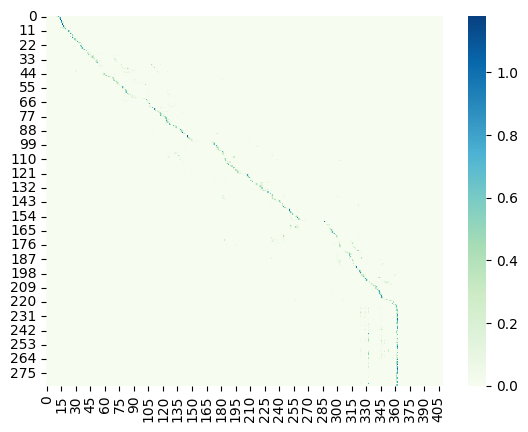

In [ ]:
###  Now let's train the encoder to master the encoder input ranges
e                   = 0
best_loss           = 10.0

checkpoint_root = os.path.join("/content/model", 'checkpointsfull4')
os.makedirs(checkpoint_root, exist_ok=True)
if USE_WANDB: wandb.watch(RPR_full_model, log="all")

checkpoint_best_loss_model_filename     = 'checkpoint-best-loss-modelfull.pth'
checkpoint_last_epoch_filename          = 'checkpoint-epochfull-'
best_loss_model_path                    = os.path.join("/content/drive/MyDrive/RPR_model", checkpoint_best_loss_model_filename)

RESUME_LOGGING = False

if RESUME_LOGGING:
    # change if you want to load best test model accordingly
    checkpoint = torch.load(os.path.join("/content/drive/MyDrive/RPR_model", "checkpointsfull4", "checkpoint-epochfull-46.pth"))

    RPR_full_model.load_state_dict(checkpoint['model_state_dict'])
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    e = checkpoint['epoch']

    print("Resuming from epoch {}".format(e+1))
    print("Epochs left: ", config['epochs']-e)
    print("Optimizer: \n", optimizer)

torch.cuda.empty_cache()
gc.collect()

epochs = config["epochs"]
for epoch in range(e, epochs):

    print("\nEpoch {}/{}".format(epoch+1, config["epochs"]))

    curr_lr = float(optimizer.param_groups[0]["lr"])

    train_loss, train_perplexity, attention_weights = train_model(RPR_full_model, train_loader, optimizer)

    print("\nEpoch {}/{}: \nTrain Loss {:.04f}\t Train Perplexity {:.04f}\t Learning Rate {:.04f}".format(
        epoch + 1, config["epochs"], train_loss, train_perplexity, curr_lr))

    if (epoch % 2 == 0):    # validate every 2 epochs to speed up training
        levenshtein_distance = validate_fast(RPR_full_model, val_loader)
        print("Val fast Levenshtein Distance {:.04f}".format(levenshtein_distance))

        if USE_WANDB: wandb.log({"train_loss"     : train_loss,
                "train_perplexity"  : train_perplexity,
                "learning_rate"     : curr_lr,
                "val_distance"      : levenshtein_distance})

    else:
        if USE_WANDB: wandb.log({"train_loss"     : train_loss,
                "train_perplexity"  : train_perplexity,
                "learning_rate"     : curr_lr})

    # plotting the encoder-nearest and decoder-nearest attention weights
    attention_keys = list(attention_weights.keys())

    # plot_attention_weights((attention_weights[attention_keys[0]][0]).cpu().detach().numpy())
    # plot_attention_weights(attention_weights[attention_keys[-1]][0].cpu().detach().numpy())

    attention_weights_decoder_self       = attention_weights[attention_keys[0]][0].cpu().detach().numpy()
    attention_weights_decoder_cross      = attention_weights[attention_keys[-1]][0].cpu().detach().numpy()
    save_attention_plot(attention_weights_decoder_cross, epoch, folder=checkpoint_root + '/')

    if config["scheduler"] == "ReduceLR":
        scheduler.step(levenshtein_distance)
    else:
        scheduler.step()

    ### Highly Recommended: Save checkpoint in drive and/or wandb if accuracy is better than your current best
    epoch_model_path = os.path.join(checkpoint_root, (checkpoint_last_epoch_filename + str(epoch) + '.pth'))
    save_model(RPR_full_model, optimizer, scheduler, ['train_loss', train_loss], epoch, epoch_model_path)
    ## wandb.save(epoch_model_path) ## Can't save on wandb for all epochs, may blow up storage

    print("Saved epoch model")

    # the first time we add the transformer encoder block, we freeze all other weights
    #   except the transformer encoder weights and train this partially-frozen model
    #   for about 3 epochs to weight initialize the transformer encoder weights.
    #   This speeds up convergence of the entire network.
    if epoch == 3:
        print("Unfreezing the Transformers")
        for param in full_model.encoder.embedding.parameters():
            param.requires_grad = True

        for param in full_model.encoder.projection.parameters():
            param.requires_grad = True

        for param in full_model.decoder.parameters():
            param.requires_grad = True

    if train_loss <= best_loss:
        best_loss = train_loss
        save_model(RPR_full_model, optimizer, scheduler, ['train_loss', train_loss], epoch, best_loss_model_path)
        # wandb.save(best_loss_model_path)
        print("Saved best training model")

### Finish your wandb run
run.finish()

In [ ]:
validate_full(RPR_full_model, val_loader)

In [ ]:
#Load best:
RPR_full_model.load_state_dict(torch.load(os.path.join("/content/drive/MyDrive/RPR_model/checkpoint-best-loss-modelfull.pth"))['model_state_dict'])

RPR_full_model.eval()

# progress bar
batch_bar = tqdm(total=len(test_loader), dynamic_ncols=True, leave=False, position=0, desc="Test", ncols=5)

all_predictions = []

for i, data in enumerate(test_loader):
    inputs, inputs_lengths = data
    inputs                 = inputs.to(device)

    with torch.inference_mode():
        greedy_predictions = RPR_full_model.recognize(inputs, inputs_lengths)

    greedy_predictions = greedy_predictions.detach().cpu().numpy()

    for batch_idx in range(greedy_predictions.shape[0]):
        pred_sliced = indices_to_chars(greedy_predictions[batch_idx], vocab= VOCAB)
        pred_string = ''.join(pred_sliced)
        all_predictions.append(pred_string)

    batch_bar.update()

Test: 100%|██████████| 11/11 [14:42<00:00, 61.74s/it]

In [ ]:
# %cd /content/
df = pd.DataFrame({
    "index" : list(range(len(all_predictions))),
    "label" : all_predictions
})

df.to_csv("/content/drive/MyDrive/RPR_model/submission_full_5.csv", index=False)

In [ ]:
RPR_full_model, optimizer, scheduler, epoch, _ = load_model("/content/drive/MyDrive/RPR_model/checkpoint-best-loss-modelfull.pth", RPR_full_model, "train_loss", optimizer, scheduler)

In [ ]:
!wandb login


Epoch 101/280



Epoch 101/280: 
Train Loss 0.9242	 Train Perplexity 2.5354	 Learning Rate 0.0000


Val fast Levenshtein Distance 87.7062
Saved epoch model
Saved best training model

Epoch 102/280



Epoch 102/280: 
Train Loss 0.9101	 Train Perplexity 2.5076	 Learning Rate 0.0000
Saved epoch model
Saved best training model

Epoch 103/280



Epoch 103/280: 
Train Loss 0.9075	 Train Perplexity 2.5002	 Learning Rate 0.0000


...


Epoch 278/280: 
Train Loss 0.7857	 Train Perplexity 2.2441	 Learning Rate 0.0000
Saved epoch model

Epoch 279/280



Epoch 279/280: 
Train Loss 0.7705	 Train Perplexity 2.1995	 Learning Rate 0.0000


Val fast Levenshtein Distance 79.6211
Saved epoch model

Epoch 280/280



Epoch 280/280: 
Train Loss 0.7589	 Train Perplexity 2.1648	 Learning Rate 0.0000
Saved epoch model


learning_rate,███▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▅▄▃▂▂▁▁▂▃▁▁▃▁▁▁▂▂▂▂▁▃▂▂▁▁▂▂▂▂▂▁▂▁▁▂▂▂▂
train_perplexity,██▆▅▅▅▅▅▄▄▂▂▂▂▃▂▂▂▃▁▂▁▁▂▂▂▂▂▁▃▃▂▁▁▁▁▁▃▂▁
val_distance,▇▆█▅▅▅▃▂▂▃▂▂▃▃▂▂▂▃▃▁▁▂▂▁▂▁▂▂▄▂▁▂▂▂▂▂▂▁▁▃
learning_rate,0.0
train_loss,0.75891
train_perplexity,2.16477
val_distance,79.62109


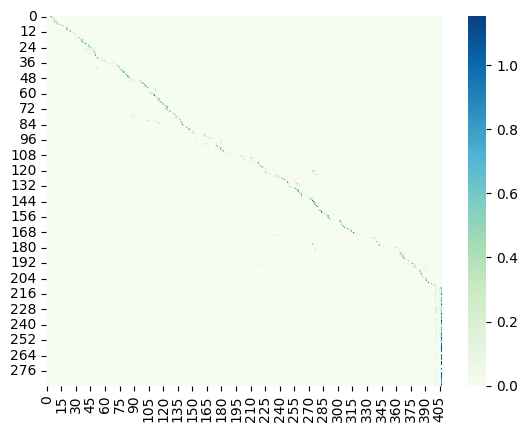

In [ ]:
###  Now let's train the encoder to master the encoder input ranges
e                   = 100
best_loss           = 10.0

checkpoint_root = os.path.join("/content/model", 'checkpointsfull4')
os.makedirs(checkpoint_root, exist_ok=True)
if USE_WANDB: wandb.watch(RPR_full_model, log="all")

checkpoint_best_loss_model_filename     = 'checkpoint-best-loss-modelfull.pth'
checkpoint_last_epoch_filename          = 'checkpoint-epochfull-'
best_loss_model_path                    = os.path.join("/content/drive/MyDrive/RPR_after", checkpoint_best_loss_model_filename)

RESUME_LOGGING = False

if RESUME_LOGGING:
    # change if you want to load best test model accordingly
    checkpoint = torch.load(os.path.join("/content/drive/MyDrive/RPR_after", "checkpointsfull4", "checkpoint-epochfull-46.pth"))

    RPR_full_model.load_state_dict(checkpoint['model_state_dict'])
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    e = checkpoint['epoch']

    print("Resuming from epoch {}".format(e+1))
    print("Epochs left: ", config['epochs']-e)
    print("Optimizer: \n", optimizer)

torch.cuda.empty_cache()
gc.collect()

epochs = config["epochs"]
for epoch in range(e, epochs):

    print("\nEpoch {}/{}".format(epoch+1, config["epochs"]))

    curr_lr = float(optimizer.param_groups[0]["lr"])

    train_loss, train_perplexity, attention_weights = train_model(RPR_full_model, train_loader, optimizer)

    print("\nEpoch {}/{}: \nTrain Loss {:.04f}\t Train Perplexity {:.04f}\t Learning Rate {:.04f}".format(
        epoch + 1, config["epochs"], train_loss, train_perplexity, curr_lr))

    if (epoch % 2 == 0):    # validate every 2 epochs to speed up training
        levenshtein_distance = validate_fast(RPR_full_model, val_loader)
        print("Val fast Levenshtein Distance {:.04f}".format(levenshtein_distance))

        if USE_WANDB: wandb.log({"train_loss"     : train_loss,
                "train_perplexity"  : train_perplexity,
                "learning_rate"     : curr_lr,
                "val_distance"      : levenshtein_distance})

    else:
        if USE_WANDB: wandb.log({"train_loss"     : train_loss,
                "train_perplexity"  : train_perplexity,
                "learning_rate"     : curr_lr})

    # plotting the encoder-nearest and decoder-nearest attention weights
    attention_keys = list(attention_weights.keys())

    # plot_attention_weights((attention_weights[attention_keys[0]][0]).cpu().detach().numpy())
    # plot_attention_weights(attention_weights[attention_keys[-1]][0].cpu().detach().numpy())

    attention_weights_decoder_self       = attention_weights[attention_keys[0]][0].cpu().detach().numpy()
    attention_weights_decoder_cross      = attention_weights[attention_keys[-1]][0].cpu().detach().numpy()
    save_attention_plot(attention_weights_decoder_cross, epoch, folder=checkpoint_root + '/')

    if config["scheduler"] == "ReduceLR":
        scheduler.step(levenshtein_distance)
    else:
        scheduler.step()

    ### Highly Recommended: Save checkpoint in drive and/or wandb if accuracy is better than your current best
    epoch_model_path = os.path.join(checkpoint_root, (checkpoint_last_epoch_filename + str(epoch) + '.pth'))
    save_model(RPR_full_model, optimizer, scheduler, ['train_loss', train_loss], epoch, epoch_model_path)
    ## wandb.save(epoch_model_path) ## Can't save on wandb for all epochs, may blow up storage

    print("Saved epoch model")

    # the first time we add the transformer encoder block, we freeze all other weights
    #   except the transformer encoder weights and train this partially-frozen model
    #   for about 3 epochs to weight initialize the transformer encoder weights.
    #   This speeds up convergence of the entire network.
    if epoch == 3:
        print("Unfreezing the Transformers")
        for param in full_model.encoder.embedding.parameters():
            param.requires_grad = True

        for param in full_model.encoder.projection.parameters():
            param.requires_grad = True

        for param in full_model.decoder.parameters():
            param.requires_grad = True

    if train_loss <= best_loss:
        best_loss = train_loss
        save_model(RPR_full_model, optimizer, scheduler, ['train_loss', train_loss], epoch, best_loss_model_path)
        # wandb.save(best_loss_model_path)
        print("Saved best training model")

### Finish your wandb run
run.finish()

In [ ]:
validate_full(RPR_full_model, val_loader)

Val:   9%|▉         | 1/11 [01:19<13:11, 79.16s/it, running_distance=82.0820]


Ground Truth :  WE RANGE WIDER LAST LONGER AND ESCAPE MORE AND MORE FROM INTENSITY TOWARDS UNDERSTANDING
Prediction   :  THE RAINED WATER AND THE SPEAK MORE FROM INCANSITY COURSE ON THEIR STANDING


Val:  18%|█▊        | 2/11 [02:33<11:25, 76.17s/it, running_distance=75.5527]


Ground Truth :  NOW HIS MIDDLE HORSE WAS BEING ALMOST DRAGGED BY THE OTHER TWO
Prediction   :  NOW WAS NO HORSE WAS BEING ON THE STRANGE BY THE EDGE OF HIS HEART OF HIS HEART OF HIS HEAD OF HIS HEAD OF HIS HEAD OF HIS HEAD OF HIS HEAD OF HIS HEAD


Val:  27%|██▋       | 3/11 [03:57<10:37, 79.66s/it, running_distance=78.7227]

...


Ground Truth :  HIS OWN SKIN HAD SIZZLED UNDER THE RED HOT BRAND HE MURMURED SOFTLY
Prediction   :  IS ONCE COULD HAVE BEEN TO THE RECOGNIZE OF LITTLE THE WAY


Val:  91%|█████████ | 10/11 [14:22<01:22, 82.32s/it, running_distance=75.8164]


Ground Truth :  SHE ASKED DIRECTLY IF HER FATHER WAS DEAD
Prediction   :  SHE ASKED THE REPLIED FOR FOUND IT WAS DEAD OF HIS HEAD OF HIS HEAD OF HIS HEAD OF HIS HEAD OF HIS HEAD OF HIS HEAD OF HIS HEAD OF HIS HEAD OF HIS HEAD OF HIS HEAD



Ground Truth :  THOU LIKE ARCTURUS STEADFAST IN THE SKIES WITH TARDY SENSE GUIDEST THY KINGDOM FAIR BEARING ALONE THE LOAD OF LIBERTY
Prediction   :  DOWN I HAVE TO REST STILL ASKED THEM THE STAYS WITH TARTY SENSE DID ITS BY CAME IN FAIR BEING A LONG OF LIVING


76.74282322790846

In [ ]:
#Load best:
RPR_full_model.load_state_dict(torch.load(os.path.join("/content/drive/MyDrive/RPR_after/checkpoint-best-loss-modelfull.pth"))['model_state_dict'])

RPR_full_model.eval()

# progress bar
batch_bar = tqdm(total=len(test_loader), dynamic_ncols=True, leave=False, position=0, desc="Test", ncols=5)

all_predictions = []

for i, data in enumerate(test_loader):
    inputs, inputs_lengths = data
    inputs                 = inputs.to(device)

    with torch.inference_mode():
        greedy_predictions = RPR_full_model.recognize(inputs, inputs_lengths)

    greedy_predictions = greedy_predictions.detach().cpu().numpy()

    for batch_idx in range(greedy_predictions.shape[0]):
        pred_sliced = indices_to_chars(greedy_predictions[batch_idx], vocab= VOCAB)
        pred_string = ''.join(pred_sliced)
        all_predictions.append(pred_string)

    batch_bar.update()

Test: 100%|██████████| 11/11 [14:49<00:00, 55.39s/it]

In [ ]:
# %cd /content/
df = pd.DataFrame({
    "index" : list(range(len(all_predictions))),
    "label" : all_predictions
})

df.to_csv("/content/drive/MyDrive/RPR_after/submission_full_6.csv", index=False)